In [ ]:
# Cell 1: Install and Import Required Libraries
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from scipy.special import expit
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


In [ ]:
# Cell 2: Load and Preprocess IMDb Dataset
print("Loading IMDb dataset...")
imdb_dataset = load_dataset("stanfordnlp/imdb")

# Display dataset structure
print(f"\nDataset structure:")
print(f"Train samples: {len(imdb_dataset['train'])}")
print(f"Test samples: {len(imdb_dataset['test'])}")
print(f"\nSample data:")
print(imdb_dataset['train'][0])

# Create validation split from training data (20% of train)
imdb_splits = imdb_dataset['train'].train_test_split(test_size=0.2, seed=42)
train_dataset = imdb_splits['train']
val_dataset = imdb_splits['test']     # 5k samples
test_dataset = imdb_dataset['test']         # 25k samples

print(f"\nFinal splits:")
print(f"Training: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

# Initialize tokenizer (using DistilBERT for efficiency)
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenization function
def preprocess_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=512
    )

# Apply tokenization
print("\nTokenizing datasets...")
train_dataset = train_dataset.map(preprocess_function, batched=True)
val_dataset = val_dataset.map(preprocess_function, batched=True)
test_dataset = test_dataset.map(preprocess_function, batched=True)

# Rename label column to labels (required by Trainer)
train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

# Set format for PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

Loading IMDb dataset...



Dataset structure:
Train samples: 25000
Test samples: 25000

Sample data:
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was co


Label distribution DataFrame:
      Dataset  Label  Count
0       Train      0  10006
1       Train      1   9994
2  Validation      0   2494
3  Validation      1   2506
4        Test      0  12500
5        Test      1  12500


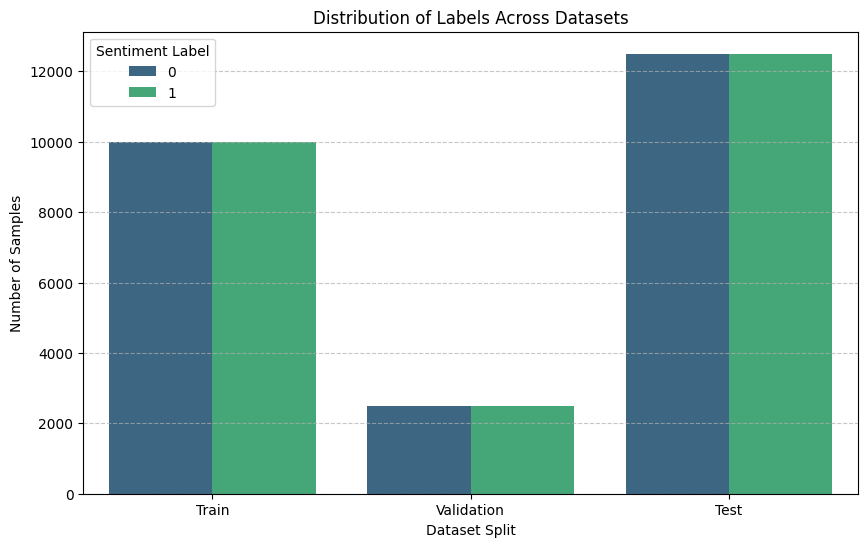

In [ ]:
# 1. Extract the 'labels' column
train_labels = [item['labels'].item() for item in train_dataset]
val_labels = [item['labels'].item() for item in val_dataset]
test_labels = [item['labels'].item() for item in test_dataset]

# 2. Calculate value counts for each label
train_counts = pd.Series(train_labels).value_counts().sort_index()
val_counts = pd.Series(val_labels).value_counts().sort_index()
test_counts = pd.Series(test_labels).value_counts().sort_index()

# 3. Create a pandas DataFrame to store these label counts
data = []
for label, count in train_counts.items():
    data.append({'Dataset': 'Train', 'Label': label, 'Count': count})
for label, count in val_counts.items():
    data.append({'Dataset': 'Validation', 'Label': label, 'Count': count})
for label, count in test_counts.items():
    data.append({'Dataset': 'Test', 'Label': label, 'Count': count})

label_distribution_df = pd.DataFrame(data)

print("\nLabel distribution DataFrame:")
print(label_distribution_df)

# 4. Use seaborn.barplot to create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Dataset', y='Count', hue='Label', data=label_distribution_df, palette='viridis')

# 5. Add title and labels to the plot
plt.title('Distribution of Labels Across Datasets')
plt.xlabel('Dataset Split')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.legend(title='Sentiment Label')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Display the plot
plt.show()


Descriptive statistics of training text lengths:
count    20000.000000
mean       275.594900
std        139.482068
min         13.000000
25%        168.000000
50%        233.000000
75%        383.000000
max        512.000000
dtype: float64


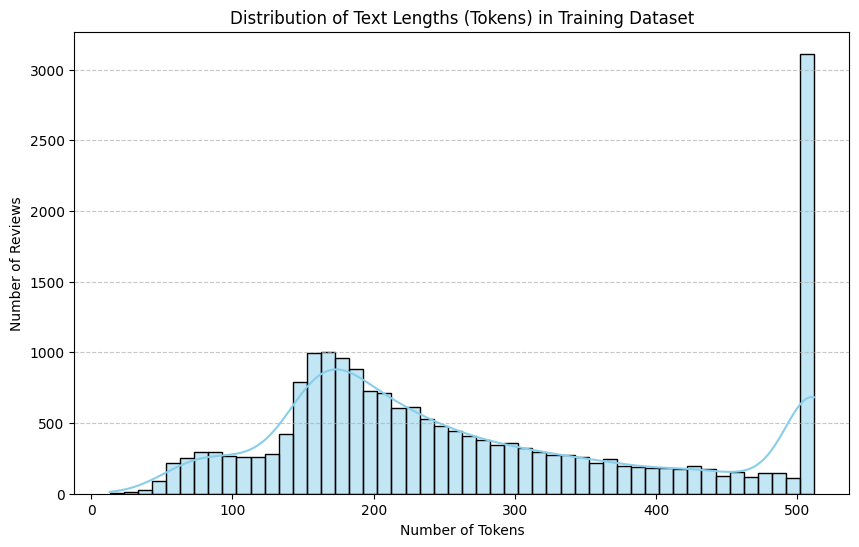

In [ ]:
# 1. Extract the length of 'input_ids' for each sample in the training dataset
train_text_lengths = [item['attention_mask'].sum().item() for item in train_dataset]

# 2. Convert the list of lengths to a pandas Series for easier analysis
text_lengths_series = pd.Series(train_text_lengths)

# 3. Print descriptive statistics of the text lengths
print("\nDescriptive statistics of training text lengths:")
print(text_lengths_series.describe())

# 4. Create a histogram to visualize the distribution of text lengths
plt.figure(figsize=(10, 6))
sns.histplot(text_lengths_series, bins=50, kde=True, color='skyblue')

# 5. Add title and labels to the plot
plt.title('Distribution of Text Lengths (Tokens) in Training Dataset')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Display the plot
plt.show()

In [ ]:
print("Initializing model...")
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
).to(device)

# Define training arguments for faster training
training_args = TrainingArguments(
    output_dir='./imdb_sentiment_model',
    num_train_epochs=3,                # Updated to 3 epochs
    per_device_train_batch_size=32,    # Increased batch size for speed
    per_device_eval_batch_size=64,     # Increased eval batch size
    fp16=torch.cuda.is_available(),    # Enable Mixed Precision training for speedup
    warmup_steps=300,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=250,                 # Reduced logging frequency to save time
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
    seed=42,
    dataloader_num_workers=2           # Use multi-process data loading
)

# Define compute metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    return {"accuracy": accuracy}

# Initialize Trainer
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Train the model
print("\nTraining model faster...")
train_result = trainer.train()

# Save the trained model
trainer.save_model('./imdb_best_model')
print("\nTraining complete! Model saved.")

Initializing model...


DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Training model faster...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.273594,0.211526,0.912600
2,0.146122,0.208961,0.924200
3,0.057281,0.281500,0.927600


There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training complete! Model saved.


In [ ]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Calculate Expected Calibration Error (ECE)
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # Find samples in this bin
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece

def brier_score(y_true, y_prob):
    """
    Calculate Brier Score
    """
    return np.mean((y_true - y_prob) ** 2)

def maximum_calibration_error(y_true, y_prob, n_bins=10):
    """
    Calculate Maximum Calibration Error (MCE)
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    mce = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            mce = max(mce, np.abs(avg_confidence_in_bin - accuracy_in_bin))

    return mce

def get_predictions_and_probabilities(model, dataset, batch_size=32):
    """
    Get predictions and probability scores from model
    """
    model.eval()
    all_logits = []
    all_labels = []

    from torch.utils.data import DataLoader
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels']

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.numpy())

    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # Convert logits to probabilities
    probabilities = torch.softmax(torch.tensor(all_logits), dim=-1).numpy()
    predictions = np.argmax(probabilities, axis=-1)

    # Get probability for positive class
    positive_probs = probabilities[:, 1]

    return predictions, positive_probs, all_labels, all_logits

def evaluate_model(y_true, y_pred, y_prob, dataset_name="Dataset"):
    """
    Comprehensive evaluation with accuracy and calibration metrics
    """
    accuracy = accuracy_score(y_true, y_pred)
    ece = expected_calibration_error(y_true, y_prob)
    brier = brier_score(y_true, y_prob)
    mce = maximum_calibration_error(y_true, y_prob)

    print(f"Evaluation Results for {dataset_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Expected Calibration Error (ECE): {ece:.4f}")
    print(f"Brier Score: {brier:.4f}")
    print(f"Maximum Calibration Error (MCE): {mce:.4f}")

    return {
        'accuracy': accuracy,
        'ece': ece,
        'brier': brier,
        'mce': mce
    }

print("Calibration metrics and evaluation functions defined!")

Calibration metrics and evaluation functions defined!


Evaluation Results for IMDb Test Set (In-Domain Baseline)
Accuracy: 0.9321
Expected Calibration Error (ECE): 0.0516
Brier Score: 0.0598
Maximum Calibration Error (MCE): 0.2326

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.93      0.93     12500
    Positive       0.93      0.93      0.93     12500

    accuracy                           0.93     25000
   macro avg       0.93      0.93      0.93     25000
weighted avg       0.93      0.93      0.93     25000



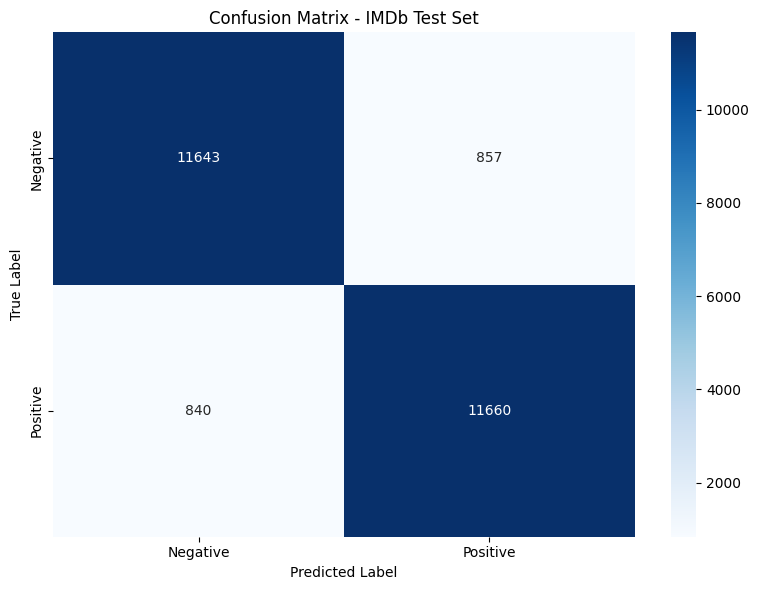

In [ ]:
# Get predictions and probabilities
test_preds, test_probs, test_labels, test_logits = get_predictions_and_probabilities(
    model, test_dataset
)

# Evaluate baseline model
baseline_results = evaluate_model(
    test_labels,
    test_preds,
    test_probs,
    dataset_name="IMDb Test Set (In-Domain Baseline)"
)

# Store for later comparison
imdb_baseline = {
    'labels': test_labels,
    'predictions': test_preds,
    'probabilities': test_probs,
    'logits': test_logits,
    'metrics': baseline_results
}

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - IMDb Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

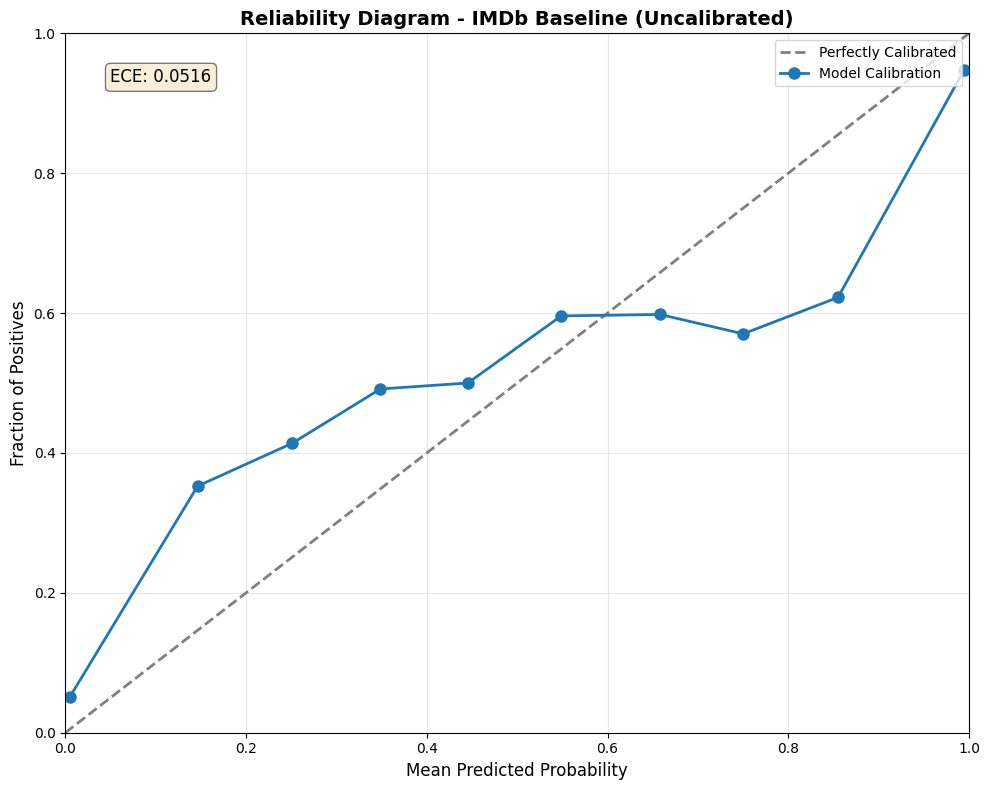

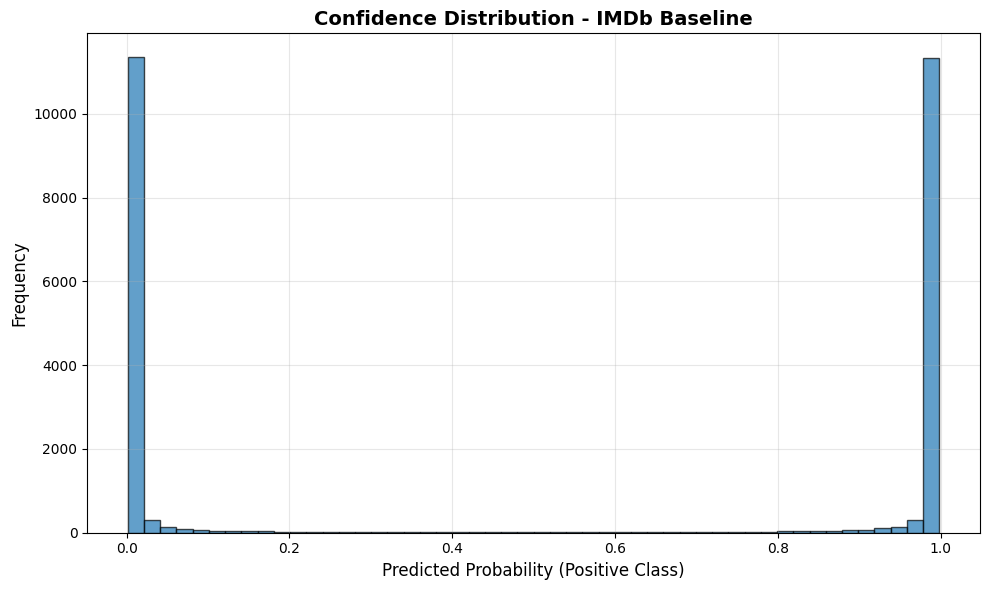

In [ ]:
def plot_reliability_diagram(y_true, y_prob, title="Reliability Diagram", n_bins=10):
    """
    Plot reliability diagram showing calibration curve
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    # Calculate calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true, y_prob, n_bins=n_bins, strategy='uniform'
    )

    # Plot perfectly calibrated line
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray',
            label='Perfectly Calibrated', linewidth=2)

    # Plot actual calibration
    ax.plot(mean_predicted_value, fraction_of_positives,
            marker='o', linewidth=2, label='Model Calibration', markersize=8)

    ax.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax.set_ylabel('Fraction of Positives', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    # Add ECE annotation
    ece = expected_calibration_error(y_true, y_prob, n_bins=n_bins)
    ax.text(0.05, 0.95, f'ECE: {ece:.4f}',
            transform=ax.transAxes, fontsize=12,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

# Plot reliability diagram for baseline
plot_reliability_diagram(
    test_labels,
    test_probs,
    title="Reliability Diagram - IMDb Baseline (Uncalibrated)"
)

# Plot confidence histogram
plt.figure(figsize=(10, 6))
plt.hist(test_probs, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Predicted Probability (Positive Class)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Confidence Distribution - IMDb Baseline', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Option 1: Amazon Reviews (different domain)
try:
    print("\nLoading Amazon Polarity dataset (product reviews)...")
    amazon_dataset = load_dataset("amazon_polarity", split='test[:5000]')

    # Preprocess Amazon dataset
    def preprocess_amazon(examples):
        # Amazon has 'content' field, map to 'text'
        texts = [title + " " + content for title, content in
                 zip(examples['title'], examples['content'])]
        tokenized = tokenizer(texts, truncation=True, padding='max_length', max_length=512)
        # Amazon labels: 0=negative, 1=positive (same as IMDb)
        tokenized['labels'] = examples['label']
        return tokenized

    amazon_dataset = amazon_dataset.map(preprocess_amazon, batched=True)
    amazon_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

    print(f"Amazon dataset loaded: {len(amazon_dataset)} samples")
    domain_shift_datasets = {'Amazon Reviews': amazon_dataset}
except Exception as e:
    print(f"Could not load Amazon dataset: {e}")
    domain_shift_datasets = {}

# Option 2: Cardiff NLP Reviews (Filtered for Binary Comparison)
try:
    print("\nLoading CardiffNLP dataset (tweet sentiment)...")
    # The raw dataset has 3 classes: 0 -> Negative, 1 -> Neutral, 2 -> Positive
    cardiffnlp_full = load_dataset("cardiffnlp/tweet_eval", "sentiment", split='test[:5000]')

    # Filter to only keep Negative (0) and Positive (2) for binary comparison
    # Then remap label 2 (Positive) to 1 to match our model's labels
    cardiffnlp_binary = cardiffnlp_full.filter(lambda x: x['label'] != 1)

    def preprocess_cardiffnlp(examples):
        tokenized = tokenizer(examples['text'], truncation=True, padding='max_length', max_length=512)
        # Map: 0 (Neg) stays 0, 2 (Pos) becomes 1
        tokenized['labels'] = [1 if l == 2 else 0 for l in examples['label']]
        return tokenized

    cardiffnlp_dataset = cardiffnlp_binary.map(preprocess_cardiffnlp, batched=True)
    cardiffnlp_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

    print(f"CardiffNLP dataset loaded and filtered: {len(cardiffnlp_dataset)} samples")
    domain_shift_datasets['CardiffNLP Reviews'] = cardiffnlp_dataset
except Exception as e:
    print(f"Could not load CardiffNLP dataset: {e}")

# Option 3: Create synthetic domain shift from IMDb (if other datasets unavailable)
if not domain_shift_datasets:
    print("\nCreating synthetic domain-shifted data from IMDb...")
    synthetic_shift = test_dataset.select(range(5000))
    domain_shift_datasets['Synthetic Shift'] = synthetic_shift

print(f"\nDomain shift datasets available: {list(domain_shift_datasets.keys())}")


Loading Amazon Polarity dataset (product reviews)...


Amazon dataset loaded: 5000 samples

Loading CardiffNLP dataset (tweet sentiment)...


CardiffNLP dataset loaded and filtered: 2534 samples

Domain shift datasets available: ['Amazon Reviews', 'CardiffNLP Reviews']


Evaluating on: Amazon Reviews
Evaluation Results for Amazon Reviews
Accuracy: 0.9126
Expected Calibration Error (ECE): 0.0605
Brier Score: 0.0742
Maximum Calibration Error (MCE): 0.3132


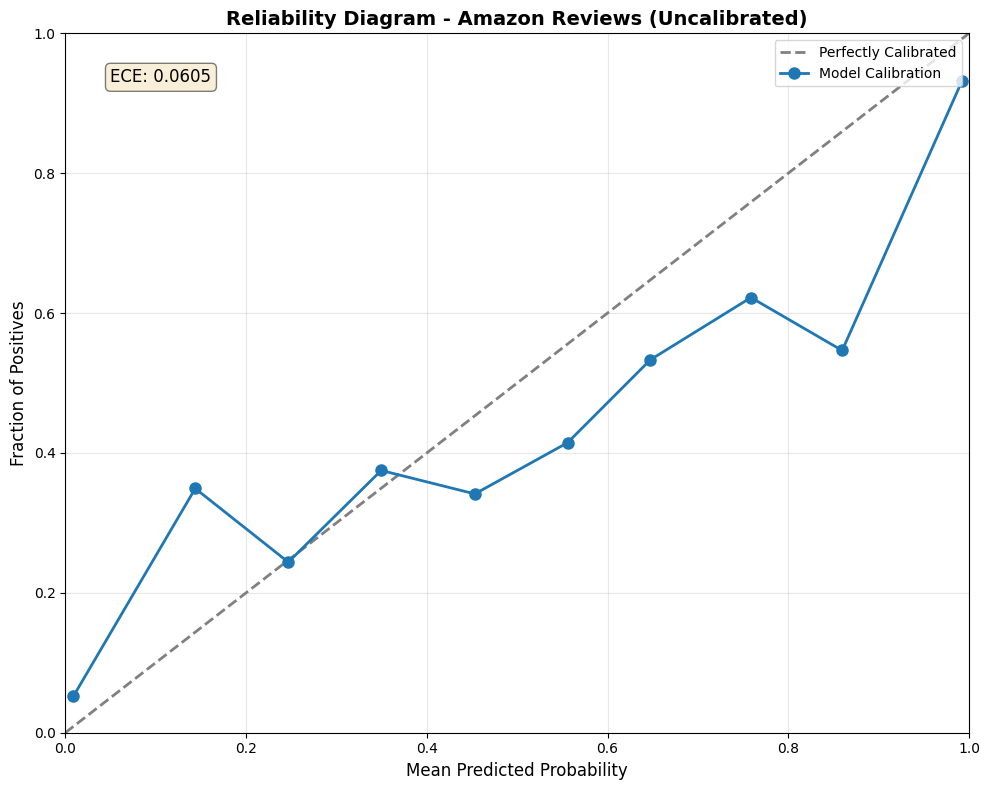

Evaluating on: CardiffNLP Reviews
Evaluation Results for CardiffNLP Reviews
Accuracy: 0.7877
Expected Calibration Error (ECE): 0.0899
Brier Score: 0.1538
Maximum Calibration Error (MCE): 0.1391


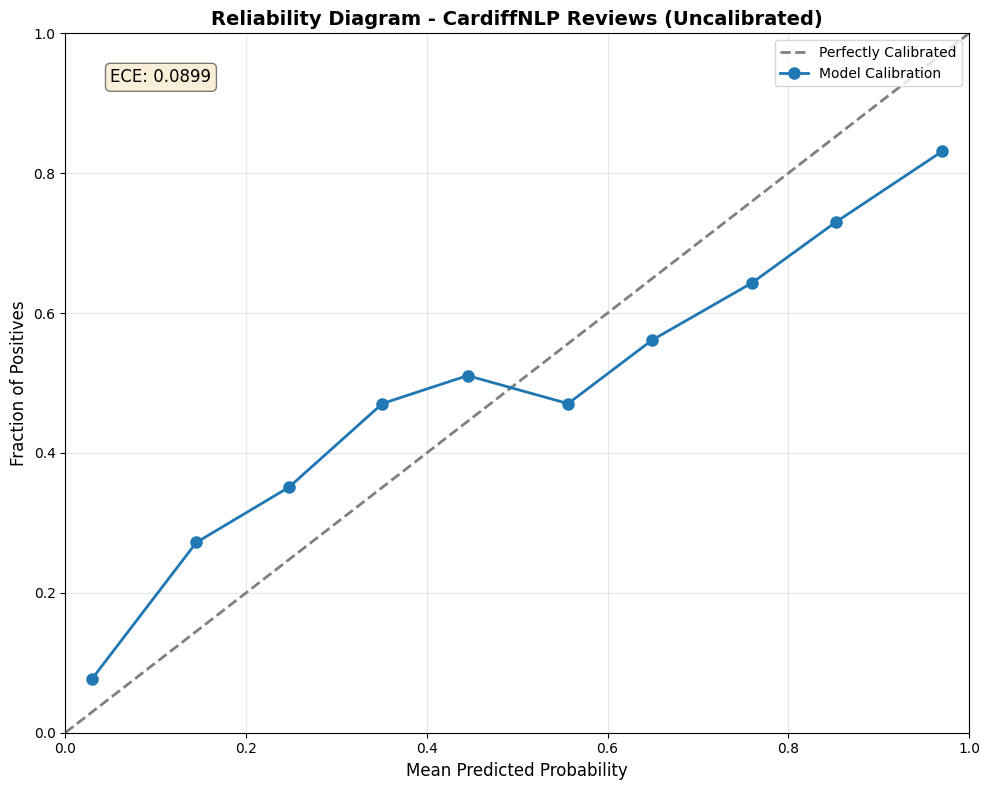

DOMAIN SHIFT ANALYSIS SUMMARY

Metrics Comparison:
          IMDb (In-Domain)  Amazon Reviews  CardiffNLP Reviews
accuracy            0.9321          0.9126              0.7877
ece                 0.0516          0.0605              0.0899
brier               0.0598          0.0742              0.1538
mce                 0.2326          0.3132              0.1391

Amazon Reviews:
  Accuracy Drop: 0.0195 (1.95%)
  ECE Increase: 0.0089

CardiffNLP Reviews:
  Accuracy Drop: 0.1444 (14.44%)
  ECE Increase: 0.0383


In [ ]:
domain_shift_results = {}

for domain_name, domain_dataset in domain_shift_datasets.items():
    print(f"Evaluating on: {domain_name}")

    # Get predictions
    domain_preds, domain_probs, domain_labels, domain_logits = get_predictions_and_probabilities(
        model, domain_dataset
    )

    # Evaluate
    results = evaluate_model(
        domain_labels,
        domain_preds,
        domain_probs,
        dataset_name=domain_name
    )

    # Store results
    domain_shift_results[domain_name] = {
        'labels': domain_labels,
        'predictions': domain_preds,
        'probabilities': domain_probs,
        'logits': domain_logits,
        'metrics': results
    }

    # Plot reliability diagram for this domain
    plot_reliability_diagram(
        domain_labels,
        domain_probs,
        title=f"Reliability Diagram - {domain_name} (Uncalibrated)"
    )

# Compare domain shift results
print("DOMAIN SHIFT ANALYSIS SUMMARY")

comparison_df = pd.DataFrame({
    'IMDb (In-Domain)': baseline_results,
    **{name: results['metrics'] for name, results in domain_shift_results.items()}
})

print("\nMetrics Comparison:")
print(comparison_df.round(4))

# Calculate degradation
for domain_name in domain_shift_results.keys():
    acc_drop = baseline_results['accuracy'] - domain_shift_results[domain_name]['metrics']['accuracy']
    ece_increase = domain_shift_results[domain_name]['metrics']['ece'] - baseline_results['ece']
    print(f"\n{domain_name}:")
    print(f"  Accuracy Drop: {acc_drop:.4f} ({acc_drop*100:.2f}%)")
    print(f"  ECE Increase: {ece_increase:.4f}")

In [ ]:
val_preds, val_probs, val_labels, val_logits = get_predictions_and_probabilities(
    model, val_dataset
)

class TemperatureScaling:
    """
    Temperature Scaling calibration method
    """
    def __init__(self):
        self.temperature = 1.0

    def fit(self, logits, labels, lr=0.01, max_iter=100):
        """
        Learn optimal temperature parameter
        """
        logits_tensor = torch.tensor(logits, dtype=torch.float32)
        labels_tensor = torch.tensor(labels, dtype=torch.long)

        # Initialize temperature
        temperature = torch.nn.Parameter(torch.ones(1) * 1.5)
        optimizer = torch.optim.LBFGS([temperature], lr=lr, max_iter=max_iter)

        def eval_loss():
            optimizer.zero_grad()
            loss = torch.nn.functional.cross_entropy(logits_tensor / temperature, labels_tensor)
            loss.backward()
            return loss

        optimizer.step(eval_loss)
        self.temperature = temperature.item()
        print(f"Optimal temperature: {self.temperature:.4f}")
        return self

    def predict_proba(self, logits):
        """
        Apply temperature scaling to logits
        """
        scaled_logits = logits / self.temperature
        probs = torch.softmax(torch.tensor(scaled_logits), dim=-1).numpy()
        return probs[:, 1]  # Return probability for positive class

class PlattScaling:
    """
    Platt Scaling (Logistic Regression on logits)
    """
    def __init__(self):
        self.model = LogisticRegression(solver='lbfgs', max_iter=1000)

    def fit(self, logits, labels):
        """
        Fit logistic regression on uncalibrated logits
        """
        # Use logits for positive class
        logits_pos = logits[:, 1].reshape(-1, 1)
        self.model.fit(logits_pos, labels)
        return self

    def predict_proba(self, logits):
        """
        Apply Platt scaling
        """
        logits_pos = logits[:, 1].reshape(-1, 1)
        probs = self.model.predict_proba(logits_pos)
        return probs[:, 1]

class IsotonicCalibration:
    """
    Isotonic Regression calibration
    """
    def __init__(self):
        self.model = IsotonicRegression(out_of_bounds='clip')

    def fit(self, probs, labels):
        """
        Fit isotonic regression on uncalibrated probabilities
        """
        self.model.fit(probs, labels)
        return self

    def predict_proba(self, probs):
        """
        Apply isotonic calibration
        """
        return self.model.predict(probs)

# Train calibration methods
print("Training Calibration Methods on Validation Set")
# Temperature Scaling
print("\n1. Temperature Scaling...")
temp_scaler = TemperatureScaling()
temp_scaler.fit(val_logits, val_labels)

# Platt Scaling
print("\n2. Platt Scaling...")
platt_scaler = PlattScaling()
platt_scaler.fit(val_logits, val_labels)

# Isotonic Regression
print("\n3. Isotonic Regression...")
isotonic_scaler = IsotonicCalibration()
isotonic_scaler.fit(val_probs, val_labels)

print("\nAll calibration methods trained!")

# Store calibrators
calibrators = {
    'Temperature Scaling': temp_scaler,
    'Platt Scaling': platt_scaler,
    'Isotonic Regression': isotonic_scaler
}

Training Calibration Methods on Validation Set

1. Temperature Scaling...
Optimal temperature: 1.7110

2. Platt Scaling...

3. Isotonic Regression...

All calibration methods trained!


In [ ]:
calibrated_results = {}

# Apply each calibration method
for method_name, calibrator in calibrators.items():
    print(f"\n{method_name}:")

    if method_name == 'Isotonic Regression':
        # Isotonic uses probabilities
        calibrated_probs = calibrator.predict_proba(test_probs)
    else:
        # Temperature and Platt use logits
        calibrated_probs = calibrator.predict_proba(test_logits)

    # Get predictions from calibrated probabilities
    calibrated_preds = (calibrated_probs > 0.5).astype(int)

    # Evaluate calibrated model
    results = evaluate_model(
        test_labels,
        calibrated_preds,
        calibrated_probs,
        dataset_name=f"IMDb Test Set ({method_name})"
    )

    calibrated_results[method_name] = {
        'probabilities': calibrated_probs,
        'predictions': calibrated_preds,
        'metrics': results
    }

# Compare uncalibrated vs calibrated
print("CALIBRATION COMPARISON - IMDb Test Set")

comparison_data = {
    'Uncalibrated': baseline_results,
    **{name: results['metrics'] for name, results in calibrated_results.items()}
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.round(4))

# Calculate improvements
print("CALIBRATION IMPROVEMENTS")
for method_name in calibrators.keys():
    acc_change = calibrated_results[method_name]['metrics']['accuracy'] - baseline_results['accuracy']
    ece_improvement = baseline_results['ece'] - calibrated_results[method_name]['metrics']['ece']
    brier_improvement = baseline_results['brier'] - calibrated_results[method_name]['metrics']['brier']

    print(f"\n{method_name}:")
    print(f"  Accuracy Change: {acc_change:+.4f} ({acc_change*100:+.2f}%)")
    print(f"  ECE Improvement: {ece_improvement:+.4f} ({ece_improvement/baseline_results['ece']*100:+.2f}%)")
    print(f"  Brier Improvement: {brier_improvement:+.4f} ({brier_improvement/baseline_results['brier']*100:+.2f}%)")


Temperature Scaling:
Evaluation Results for IMDb Test Set (Temperature Scaling)
Accuracy: 0.9321
Expected Calibration Error (ECE): 0.0181
Brier Score: 0.0548
Maximum Calibration Error (MCE): 0.1948

Platt Scaling:
Evaluation Results for IMDb Test Set (Platt Scaling)
Accuracy: 0.9320
Expected Calibration Error (ECE): 0.0192
Brier Score: 0.0543
Maximum Calibration Error (MCE): 0.1489

Isotonic Regression:
Evaluation Results for IMDb Test Set (Isotonic Regression)
Accuracy: 0.9303
Expected Calibration Error (ECE): 0.0086
Brier Score: 0.0522
Maximum Calibration Error (MCE): 0.3931
CALIBRATION COMPARISON - IMDb Test Set

           Uncalibrated  Temperature Scaling  Platt Scaling  \
accuracy        0.9321               0.9321         0.9320   
ece             0.0516               0.0181         0.0192   
brier           0.0598               0.0548         0.0543   
mce             0.2326               0.1948         0.1489   

          Isotonic Regression  
accuracy               0.9303  

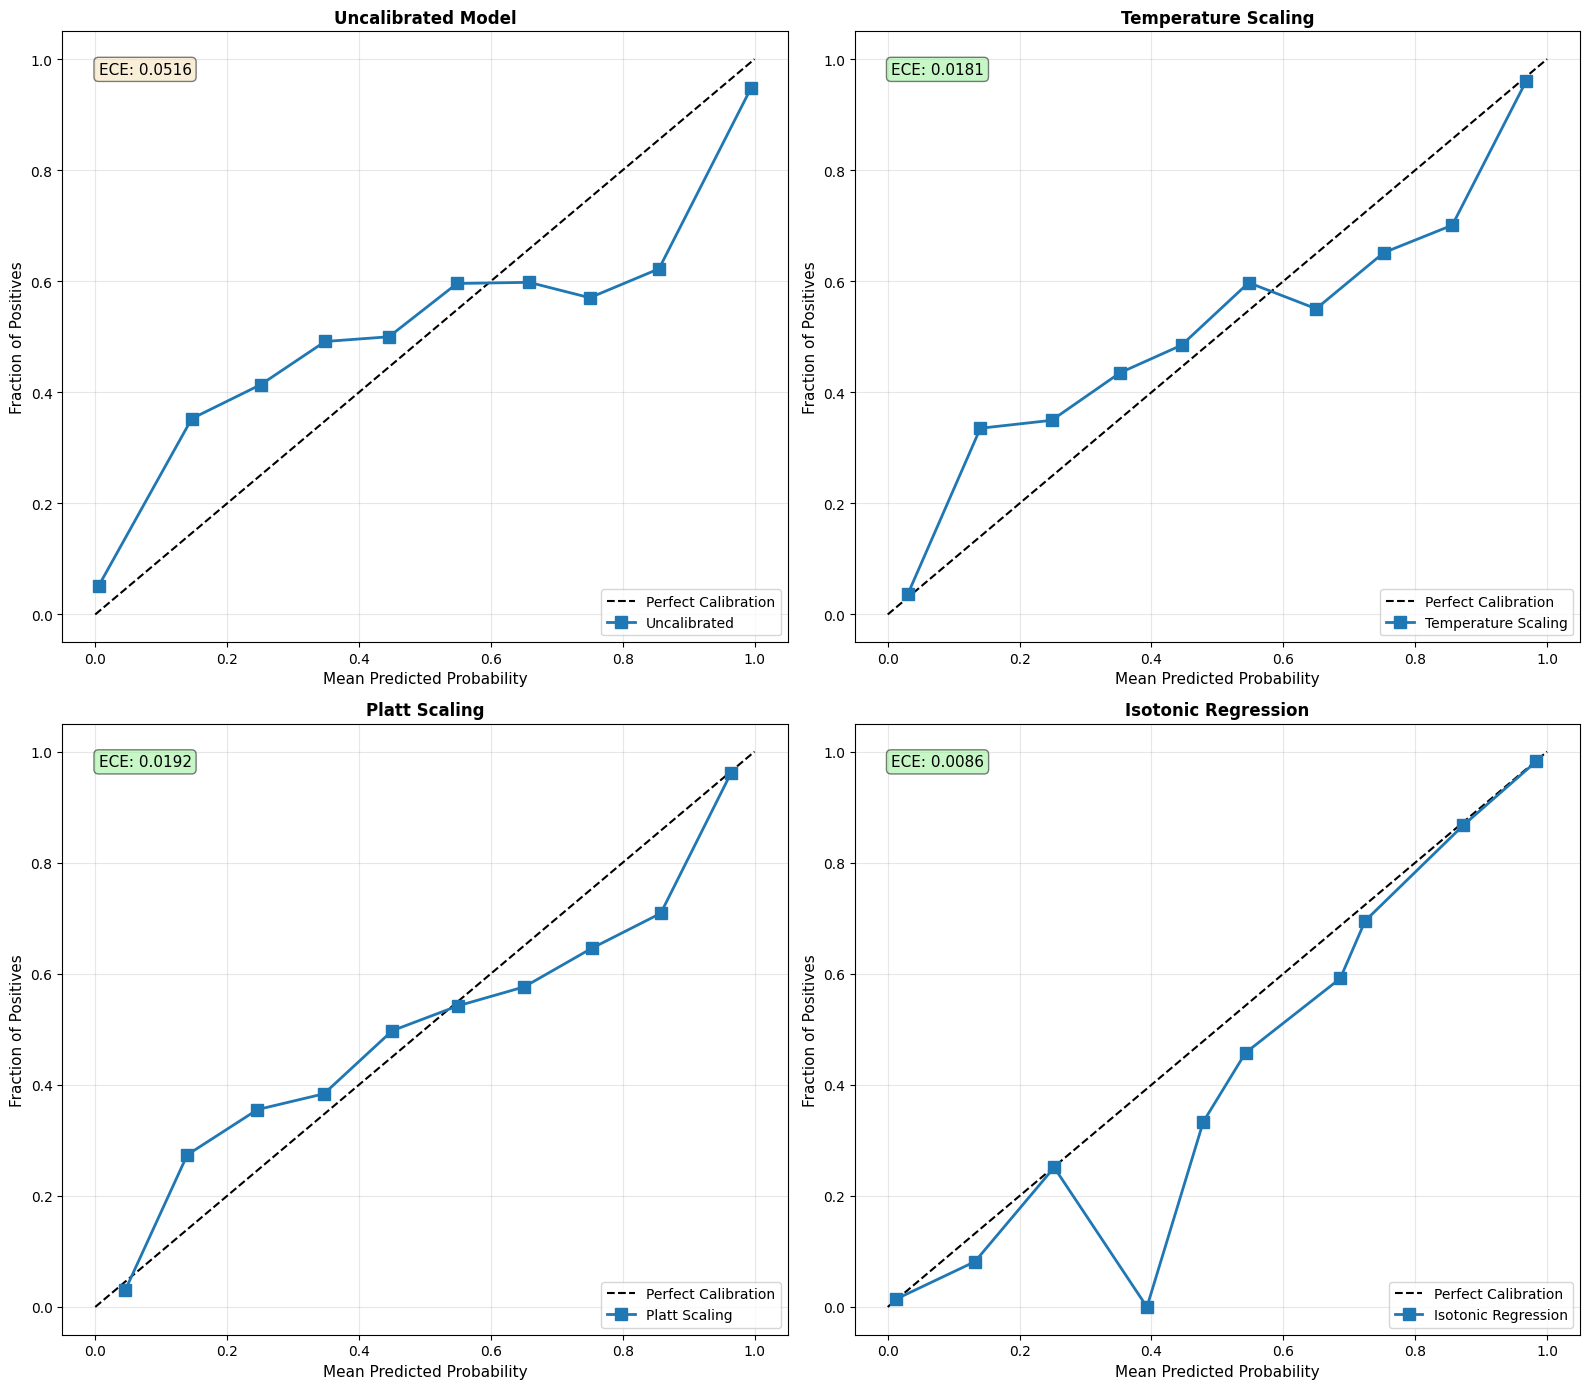

Calibration comparison plot saved as 'calibration_comparison.png'


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

# Plot uncalibrated
fraction_pos, mean_pred = calibration_curve(test_labels, test_probs, n_bins=10)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[0].plot(mean_pred, fraction_pos, 's-', label='Uncalibrated', linewidth=2, markersize=8)
axes[0].set_xlabel('Mean Predicted Probability', fontsize=11)
axes[0].set_ylabel('Fraction of Positives', fontsize=11)
axes[0].set_title('Uncalibrated Model', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f'ECE: {baseline_results["ece"]:.4f}',
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot each calibration method
for idx, (method_name, results) in enumerate(calibrated_results.items(), 1):
    calibrated_probs = results['probabilities']
    fraction_pos, mean_pred = calibration_curve(test_labels, calibrated_probs, n_bins=10)

    axes[idx].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    axes[idx].plot(mean_pred, fraction_pos, 's-', label=method_name, linewidth=2, markersize=8)
    axes[idx].set_xlabel('Mean Predicted Probability', fontsize=11)
    axes[idx].set_ylabel('Fraction of Positives', fontsize=11)
    axes[idx].set_title(method_name, fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].text(0.05, 0.95, f'ECE: {results["metrics"]["ece"]:.4f}',
                   transform=axes[idx].transAxes, fontsize=11, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.savefig('calibration_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Calibration comparison plot saved as 'calibration_comparison.png'")

In [ ]:
domain_calibrated_results = {}

for domain_name, domain_data in domain_shift_results.items():
    print(f"Domain: {domain_name}")

    domain_labels = domain_data['labels']
    domain_logits = domain_data['logits']
    domain_probs = domain_data['probabilities']

    domain_calibrated_results[domain_name] = {
        'Uncalibrated': domain_data['metrics']
    }

    # Apply each calibration method
    for method_name, calibrator in calibrators.items():
        if method_name == 'Isotonic Regression':
            calibrated_probs = calibrator.predict_proba(domain_probs)
        else:
            calibrated_probs = calibrator.predict_proba(domain_logits)

        calibrated_preds = (calibrated_probs > 0.5).astype(int)

        # Evaluate
        results = evaluate_model(
            domain_labels,
            calibrated_preds,
            calibrated_probs,
            dataset_name=f"{domain_name} ({method_name})"
        )

        domain_calibrated_results[domain_name][method_name] = results

# Create comparison dataframe for each domain
print("DOMAIN SHIFT + CALIBRATION RESULTS SUMMARY")

for domain_name in domain_shift_results.keys():
    print(f"\n{domain_name}:")
    domain_df = pd.DataFrame(domain_calibrated_results[domain_name]).round(4)
    print(domain_df)

Domain: Amazon Reviews
Evaluation Results for Amazon Reviews (Temperature Scaling)
Accuracy: 0.9126
Expected Calibration Error (ECE): 0.0244
Brier Score: 0.0683
Maximum Calibration Error (MCE): 0.2131
Evaluation Results for Amazon Reviews (Platt Scaling)
Accuracy: 0.9114
Expected Calibration Error (ECE): 0.0280
Brier Score: 0.0684
Maximum Calibration Error (MCE): 0.2067
Evaluation Results for Amazon Reviews (Isotonic Regression)
Accuracy: 0.9030
Expected Calibration Error (ECE): 0.0358
Brier Score: 0.0705
Maximum Calibration Error (MCE): 0.2420
Domain: CardiffNLP Reviews
Evaluation Results for CardiffNLP Reviews (Temperature Scaling)
Accuracy: 0.7877
Expected Calibration Error (ECE): 0.0349
Brier Score: 0.1451
Maximum Calibration Error (MCE): 0.0788
Evaluation Results for CardiffNLP Reviews (Platt Scaling)
Accuracy: 0.7904
Expected Calibration Error (ECE): 0.0484
Brier Score: 0.1455
Maximum Calibration Error (MCE): 0.0757
Evaluation Results for CardiffNLP Reviews (Isotonic Regression)


## DistilBERT Summary

DistilBERT performs strongly on the IMDb test set and shows that high classification accuracy does not automatically imply perfect calibration. The reliability diagrams indicate mild overconfidence in the uncalibrated model, while post-hoc calibration methods improve confidence reliability without materially reducing accuracy.

Under domain shift, performance remains reasonably strong on Amazon Reviews but calibration becomes weaker. On the CardiffNLP tweet sentiment dataset, the drop in both accuracy and calibration is larger, showing that stronger domain shift has a greater effect on model reliability.

---
# Part 2: RoBERTA


In [ ]:
# Cell 16: Initialize and Train Second Model - RoBERTa
print("TRAINING SECOND MODEL: RoBERTa-base")

# Fix: Identify the best calibration method for DistilBERT before storing results
ece_improvements = {
    method: baseline_results['ece'] - calibrated_results[method]['metrics']['ece']
    for method in calibrators.keys()
}
best_method = max(ece_improvements, key=ece_improvements.get)

# Store DistilBERT results for comparison
distilbert_results = {
    'model_name': 'DistilBERT',
    'baseline': baseline_results,
    'calibrated': {method: calibrated_results[method]['metrics'] for method in calibrators.keys()},
    'domain_shift': {name: data['metrics'] for name, data in domain_shift_results.items()},
    'best_method': best_method
}

# Initialize RoBERTa model
model_name_2 = "roberta-base"
print(f"\nInitializing {model_name_2}...")
tokenizer_2 = AutoTokenizer.from_pretrained(model_name_2)
model_2 = AutoModelForSequenceClassification.from_pretrained(
    model_name_2,
    num_labels=2
).to(device)

# Tokenization function for RoBERTa
def preprocess_function_roberta(examples):
    return tokenizer_2(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=512
    )

# Re-tokenize datasets for RoBERTa
print("\nTokenizing datasets for RoBERTa...")
imdb_dataset_fresh = load_dataset("stanfordnlp/imdb")
roberta_splits = imdb_dataset_fresh['train'].train_test_split(test_size=0.2, seed=42)
train_dataset_2 = roberta_splits['train'].map(preprocess_function_roberta, batched=True)
val_dataset_2 = roberta_splits['test'].map(preprocess_function_roberta, batched=True)
test_dataset_2 = imdb_dataset_fresh['test'].map(preprocess_function_roberta, batched=True)

# Rename and set format
train_dataset_2 = train_dataset_2.rename_column("label", "labels")
val_dataset_2 = val_dataset_2.rename_column("label", "labels")
test_dataset_2 = test_dataset_2.rename_column("label", "labels")
train_dataset_2.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset_2.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset_2.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

# Define training arguments for RoBERTa
training_args_2 = TrainingArguments(
    output_dir='./imdb_roberta_model',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    fp16=torch.cuda.is_available(),
    warmup_steps=300,
    weight_decay=0.01,
    logging_steps=250,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
    seed=42,
    dataloader_num_workers=2
)

# Initialize Trainer for RoBERTa
data_collator_2 = DataCollatorWithPadding(tokenizer=tokenizer_2)

trainer_2 = Trainer(
    model=model_2,
    args=training_args_2,
    train_dataset=train_dataset_2,
    eval_dataset=val_dataset_2,
    data_collator=data_collator_2,
    compute_metrics=compute_metrics
)

# Train RoBERTa model
print("\nTraining RoBERTa model...")
train_result_2 = trainer_2.train()

# Save the trained model
trainer_2.save_model('./imdb_roberta_best_model')
print("\nRoBERTa training complete! Model saved.")

TRAINING SECOND MODEL: RoBERTa-base

Initializing roberta-base...


RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Tokenizing datasets for RoBERTa...



Training RoBERTa model...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.267440,0.199174,0.924200
2,0.158659,0.177698,0.942800
3,0.086762,0.186594,0.949000


There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


RoBERTa training complete! Model saved.


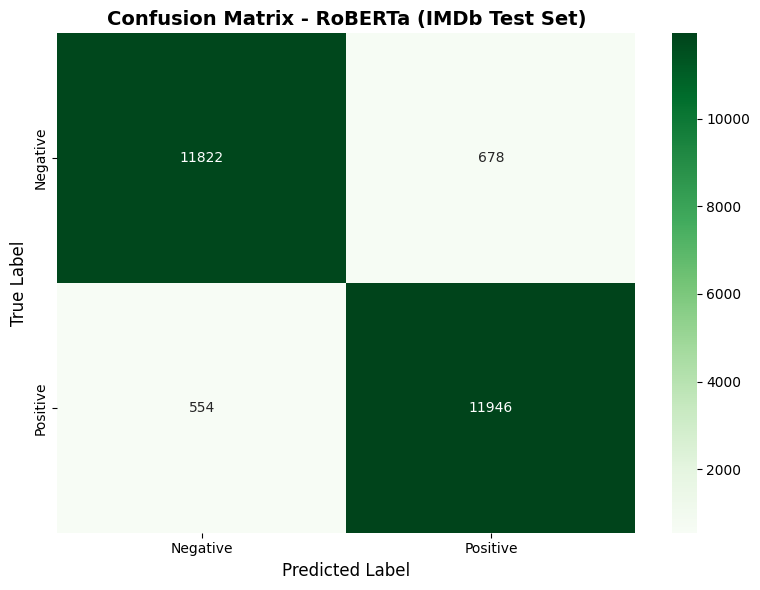

In [ ]:
# Compute the confusion matrix for RoBERTa
roberta_cm = confusion_matrix(test_labels_2, test_preds_2)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(roberta_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title('Confusion Matrix - RoBERTa (IMDb Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

EVALUATING RoBERTa - In-Domain Baseline
Evaluation Results for RoBERTa - IMDb Test Set (In-Domain Baseline)
Accuracy: 0.9507
Expected Calibration Error (ECE): 0.0362
Brier Score: 0.0436
Maximum Calibration Error (MCE): 0.3216

RoBERTa Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.95      0.95     12500
    Positive       0.95      0.96      0.95     12500

    accuracy                           0.95     25000
   macro avg       0.95      0.95      0.95     25000
weighted avg       0.95      0.95      0.95     25000



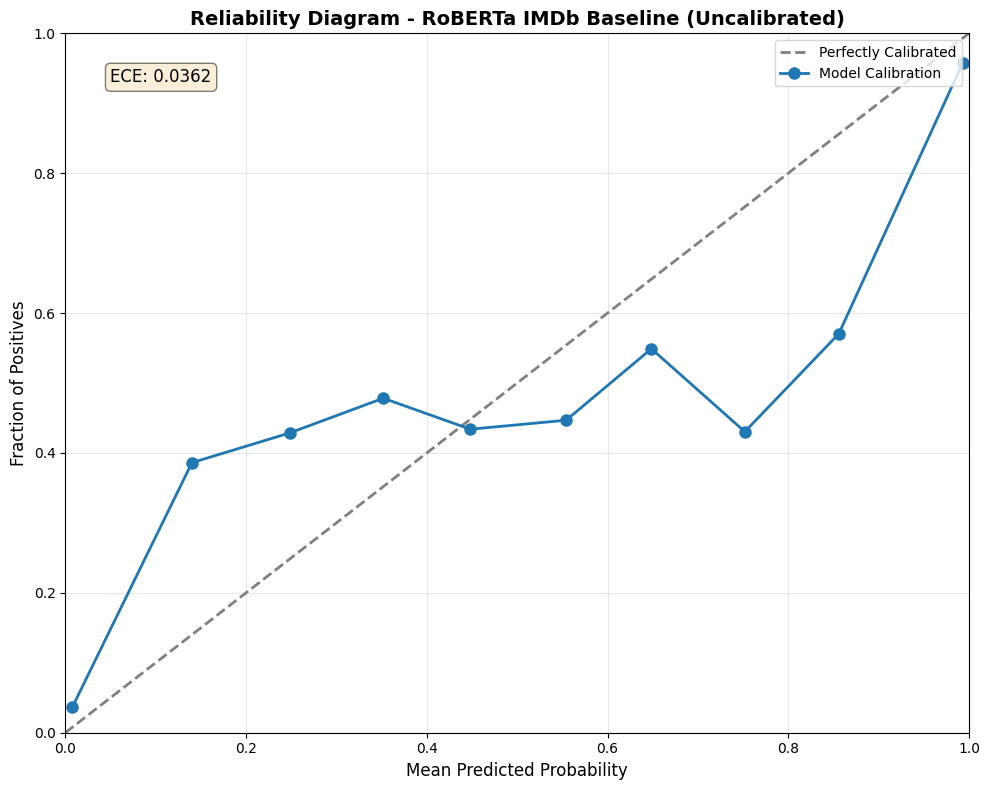

BASELINE COMPARISON: DistilBERT vs RoBERTa
          DistilBERT  RoBERTa
accuracy      0.9321   0.9507
ece           0.0516   0.0362
brier         0.0598   0.0436
mce           0.2326   0.3216

RoBERTa has higher accuracy: 0.9507 vs 0.9321
RoBERTa has better calibration (lower ECE): 0.0362 vs 0.0516


In [ ]:
# Cell 17: Evaluate RoBERTa on IMDb Test Set (Baseline)

print("EVALUATING RoBERTa - In-Domain Baseline")
# Get predictions and probabilities for RoBERTa
test_preds_2, test_probs_2, test_labels_2, test_logits_2 = get_predictions_and_probabilities(
    model_2, test_dataset_2
)

# Evaluate RoBERTa baseline
baseline_results_2 = evaluate_model(
    test_labels_2,
    test_preds_2,
    test_probs_2,
    dataset_name="RoBERTa - IMDb Test Set (In-Domain Baseline)"
)

# Store for comparison
roberta_baseline = {
    'labels': test_labels_2,
    'predictions': test_preds_2,
    'probabilities': test_probs_2,
    'logits': test_logits_2,
    'metrics': baseline_results_2
}

# Classification report
print("\nRoBERTa Classification Report:")
print(classification_report(test_labels_2, test_preds_2, target_names=['Negative', 'Positive']))

# Reliability diagram for RoBERTa
plot_reliability_diagram(
    test_labels_2,
    test_probs_2,
    title="Reliability Diagram - RoBERTa IMDb Baseline (Uncalibrated)"
)

# Compare DistilBERT vs RoBERTa baseline
print("BASELINE COMPARISON: DistilBERT vs RoBERTa")
baseline_comparison = pd.DataFrame({
    'DistilBERT': baseline_results,
    'RoBERTa': baseline_results_2
})

print(baseline_comparison.round(4))

# Determine which is better
if baseline_results_2['accuracy'] > baseline_results['accuracy']:
    print(f"\nRoBERTa has higher accuracy: {baseline_results_2['accuracy']:.4f} vs {baseline_results['accuracy']:.4f}")
else:
    print(f"\nDistilBERT has higher accuracy: {baseline_results['accuracy']:.4f} vs {baseline_results_2['accuracy']:.4f}")

if baseline_results_2['ece'] < baseline_results['ece']:
    print(f"RoBERTa has better calibration (lower ECE): {baseline_results_2['ece']:.4f} vs {baseline_results['ece']:.4f}")
else:
    print(f"DistilBERT has better calibration (lower ECE): {baseline_results['ece']:.4f} vs {baseline_results_2['ece']:.4f}")

In [ ]:
# Cell 18: Prepare Domain Shift Datasets for RoBERTa
print("Preparing Domain Shift Datasets for RoBERTa")
domain_shift_datasets_2 = {}

# Amazon Reviews for RoBERTa
try:
    print("\nLoading Amazon Polarity dataset for RoBERTa...")
    amazon_dataset_2 = load_dataset("amazon_polarity", split='test[:5000]')

    def preprocess_amazon_roberta(examples):
        texts = [title + " " + content for title, content in
                 zip(examples['title'], examples['content'])]
        tokenized = tokenizer_2(texts, truncation=True, padding='max_length', max_length=512)
        tokenized['labels'] = examples['label']
        return tokenized

    amazon_dataset_2 = amazon_dataset_2.map(preprocess_amazon_roberta, batched=True)
    amazon_dataset_2.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

    print(f"Amazon dataset loaded: {len(amazon_dataset_2)} samples")
    domain_shift_datasets_2['Amazon Reviews'] = amazon_dataset_2
except Exception as e:
    print(f"Could not load Amazon dataset: {e}")

print(f"\nDomain shift datasets available for RoBERTa: {list(domain_shift_datasets_2.keys())}")

Preparing Domain Shift Datasets for RoBERTa

Loading Amazon Polarity dataset for RoBERTa...


Amazon dataset loaded: 5000 samples

Domain shift datasets available for RoBERTa: ['Amazon Reviews']


In [ ]:
# Cell 19: Evaluate RoBERTa Under Domain Shift
print("Evaluating RoBERTa Under Domain Shift")
domain_shift_results_2 = {}

for domain_name, domain_dataset in domain_shift_datasets_2.items():
    print(f"RoBERTa Evaluation on: {domain_name}")
    # Get predictions
    domain_preds_2, domain_probs_2, domain_labels_2, domain_logits_2 = get_predictions_and_probabilities(
        model_2, domain_dataset
    )

    # Evaluate
    results_2 = evaluate_model(
        domain_labels_2,
        domain_preds_2,
        domain_probs_2,
        dataset_name=f"RoBERTa - {domain_name}"
    )

    # Store results
    domain_shift_results_2[domain_name] = {
        'labels': domain_labels_2,
        'predictions': domain_preds_2,
        'probabilities': domain_probs_2,
        'logits': domain_logits_2,
        'metrics': results_2
    }

# Compare domain shift: DistilBERT vs RoBERTa
print("DOMAIN SHIFT COMPARISON: DistilBERT vs RoBERTa")
for domain_name in domain_shift_results.keys():
    if domain_name in domain_shift_results_2:
        print(f"\n{domain_name}:")
        comparison_df = pd.DataFrame({
            'DistilBERT': domain_shift_results[domain_name]['metrics'],
            'RoBERTa': domain_shift_results_2[domain_name]['metrics']
        })
        print(comparison_df.round(4))

Evaluating RoBERTa Under Domain Shift
RoBERTa Evaluation on: Amazon Reviews
Evaluation Results for RoBERTa - Amazon Reviews
Accuracy: 0.9296
Expected Calibration Error (ECE): 0.0531
Brier Score: 0.0622
Maximum Calibration Error (MCE): 0.3729
DOMAIN SHIFT COMPARISON: DistilBERT vs RoBERTa

Amazon Reviews:
          DistilBERT  RoBERTa
accuracy      0.9126   0.9296
ece           0.0605   0.0531
brier         0.0742   0.0622
mce           0.3132   0.3729


## RoBERTa Domain-Shift Note

RoBERTa is evaluated on Amazon Reviews to test robustness outside the IMDb training domain. This allows comparison of in-domain versus out-of-domain behaviour in both accuracy and calibration.

Unlike DistilBERT, RoBERTa is not evaluated on the CardiffNLP tweet sentiment dataset in this notebook. Therefore, cross-model domain-shift comparison is limited to Amazon Reviews only.

In [ ]:
# Cell 20: Train Calibration Methods for RoBERTa
print("Training Calibration Methods for RoBERTa")
# Get validation set predictions for RoBERTa calibration training
val_preds_2, val_probs_2, val_labels_2, val_logits_2 = get_predictions_and_probabilities(
    model_2, val_dataset_2
)

# Train calibration methods for RoBERTa
print("\n1. Temperature Scaling for RoBERTa...")
temp_scaler_2 = TemperatureScaling()
temp_scaler_2.fit(val_logits_2, val_labels_2)

print("\n2. Platt Scaling for RoBERTa...")
platt_scaler_2 = PlattScaling()
platt_scaler_2.fit(val_logits_2, val_labels_2)

print("\n3. Isotonic Regression for RoBERTa...")
isotonic_scaler_2 = IsotonicCalibration()
isotonic_scaler_2.fit(val_probs_2, val_labels_2)

print("\nAll calibration methods trained for RoBERTa!")

# Store calibrators
calibrators_2 = {
    'Temperature Scaling': temp_scaler_2,
    'Platt Scaling': platt_scaler_2,
    'Isotonic Regression': isotonic_scaler_2
}

Training Calibration Methods for RoBERTa

1. Temperature Scaling for RoBERTa...
Optimal temperature: 1.5252

2. Platt Scaling for RoBERTa...

3. Isotonic Regression for RoBERTa...

All calibration methods trained for RoBERTa!


In [ ]:
# Cell 21: Apply Calibration Methods to RoBERTa
print("Applying Calibration Methods to RoBERTa - IMDb Test Set")
calibrated_results_2 = {}

# Apply each calibration method to RoBERTa
for method_name, calibrator in calibrators_2.items():
    print(f"\n{method_name}:")

    if method_name == 'Isotonic Regression':
        calibrated_probs_2 = calibrator.predict_proba(test_probs_2)
    else:
        calibrated_probs_2 = calibrator.predict_proba(test_logits_2)

    calibrated_preds_2 = (calibrated_probs_2 > 0.5).astype(int)

    # Evaluate calibrated RoBERTa
    results_2 = evaluate_model(
        test_labels_2,
        calibrated_preds_2,
        calibrated_probs_2,
        dataset_name=f"RoBERTa - IMDb Test Set ({method_name})"
    )

    calibrated_results_2[method_name] = {
        'probabilities': calibrated_probs_2,
        'predictions': calibrated_preds_2,
        'metrics': results_2
    }

# Compare uncalibrated vs calibrated for RoBERTa
print("CALIBRATION COMPARISON - RoBERTa")
comparison_data_2 = {
    'Uncalibrated': baseline_results_2,
    **{name: results['metrics'] for name, results in calibrated_results_2.items()}
}

comparison_df_2 = pd.DataFrame(comparison_data_2)
print("\n", comparison_df_2.round(4))

# Identify best method for RoBERTa
ece_improvements_2 = {
    method: baseline_results_2['ece'] - calibrated_results_2[method]['metrics']['ece']
    for method in calibrators_2.keys()
}
best_method_2 = max(ece_improvements_2, key=ece_improvements_2.get)

print(f"\nBest calibration method for RoBERTa: {best_method_2}")
print(f"  ECE Improvement: {ece_improvements_2[best_method_2]:.4f}")

Applying Calibration Methods to RoBERTa - IMDb Test Set

Temperature Scaling:
Evaluation Results for RoBERTa - IMDb Test Set (Temperature Scaling)
Accuracy: 0.9507
Expected Calibration Error (ECE): 0.0148
Brier Score: 0.0404
Maximum Calibration Error (MCE): 0.2166

Platt Scaling:
Evaluation Results for RoBERTa - IMDb Test Set (Platt Scaling)
Accuracy: 0.9507
Expected Calibration Error (ECE): 0.0138
Brier Score: 0.0406
Maximum Calibration Error (MCE): 0.2404

Isotonic Regression:
Evaluation Results for RoBERTa - IMDb Test Set (Isotonic Regression)
Accuracy: 0.9503
Expected Calibration Error (ECE): 0.0063
Brier Score: 0.0377
Maximum Calibration Error (MCE): 0.3916
CALIBRATION COMPARISON - RoBERTa

           Uncalibrated  Temperature Scaling  Platt Scaling  \
accuracy        0.9507               0.9507         0.9507   
ece             0.0362               0.0148         0.0138   
brier           0.0436               0.0404         0.0406   
mce             0.3216               0.2166   

# Part 3: GPT-2 Fine-Tuning and Calibration Evaluation

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

gpt2_name = "openai-community/gpt2"
tokenizer_gpt2 = AutoTokenizer.from_pretrained(gpt2_name)

# GPT-2 has no default padding token; reuse EOS token for batching.
if tokenizer_gpt2.pad_token is None:
    tokenizer_gpt2.pad_token = tokenizer_gpt2.eos_token

print("Loading IMDb dataset...")
imdb = load_dataset("stanfordnlp/imdb")
splits = imdb["train"].train_test_split(test_size=0.2, seed=42)
train_ds = splits["train"]
val_ds = splits["test"]
test_ds = imdb["test"]

MAX_LEN = 256

def preprocess_imdb(batch):
    return tokenizer_gpt2(batch["text"], truncation=True, padding="max_length", max_length=MAX_LEN)

train_ds = train_ds.map(preprocess_imdb, batched=True)
val_ds = val_ds.map(preprocess_imdb, batched=True)
test_ds = test_ds.map(preprocess_imdb, batched=True)

train_ds = train_ds.rename_column("label", "labels")
val_ds = val_ds.rename_column("label", "labels")
test_ds = test_ds.rename_column("label", "labels")

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Initializing GPT-2 sequence classification model...")
model_gpt2 = AutoModelForSequenceClassification.from_pretrained(gpt2_name, num_labels=2)
model_gpt2.config.pad_token_id = tokenizer_gpt2.pad_token_id
model_gpt2.to(device)

def compute_acc(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

args_gpt2 = TrainingArguments(
    output_dir="./imdb_gpt2_model",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    fp16=torch.cuda.is_available(),
    warmup_steps=300,
    weight_decay=0.01,
    logging_steps=250,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
    seed=42,
    dataloader_num_workers=2
)

trainer_gpt2 = Trainer(
    model=model_gpt2,
    args=args_gpt2,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer_gpt2),
    compute_metrics=compute_acc,
    # Removed tokenizer parameter
)

print("Training GPT-2...")
trainer_gpt2.train()
trainer_gpt2.save_model("./imdb_gpt2_best_model")
print("GPT-2 training complete.")

Using device: cuda
Loading IMDb dataset...


Initializing GPT-2 sequence classification model...


GPT2ForSequenceClassification LOAD REPORT from: openai-community/gpt2
Key                  | Status     | 
---------------------+------------+-
h.{0...11}.attn.bias | UNEXPECTED | 
score.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training GPT-2...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.301710,0.249815,0.898400
2,0.199453,0.215520,0.912800
3,0.133250,0.225228,0.918800


GPT-2 training complete.


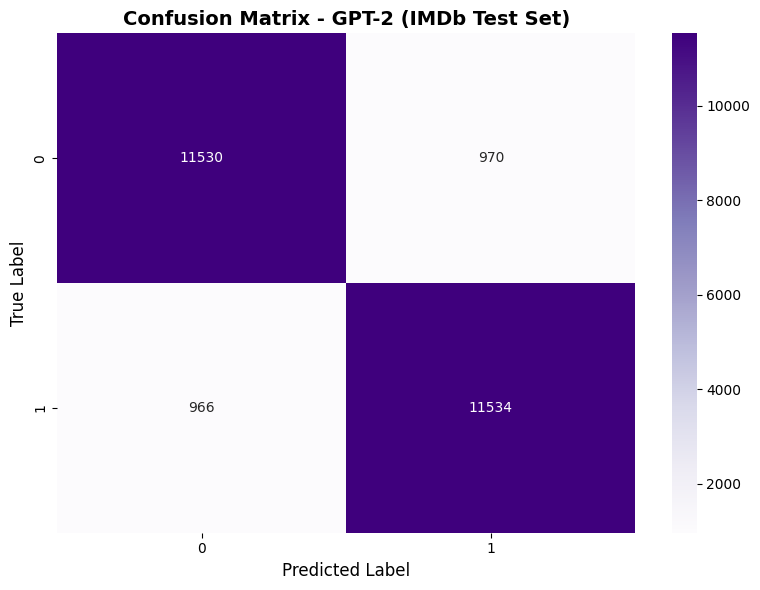

In [ ]:
# Compute the confusion matrix for GPT-2
gpt2_cm = confusion_matrix(gpt2_test_labels, gpt2_test_preds)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(gpt2_cm, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - GPT-2 (IMDb Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()


GPT-2 Baseline - IMDb Test
Accuracy: 0.9226
ECE:      0.0353
Brier:    0.0608
MCE:      0.1235

Classification report:
              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92     12500
    Positive       0.92      0.92      0.92     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000



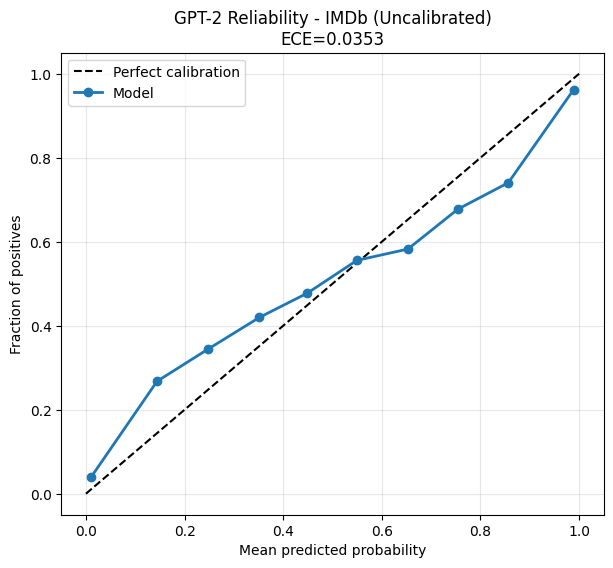


Loading Amazon Polarity for domain-shift test...



GPT-2 Baseline - Amazon (Domain Shift)
Accuracy: 0.9216
ECE:      0.0316
Brier:    0.0598
MCE:      0.2241

Classification report:
              precision    recall  f1-score   support

    Negative       0.93      0.91      0.92      2435
    Positive       0.91      0.94      0.92      2565

    accuracy                           0.92      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.92      0.92      0.92      5000



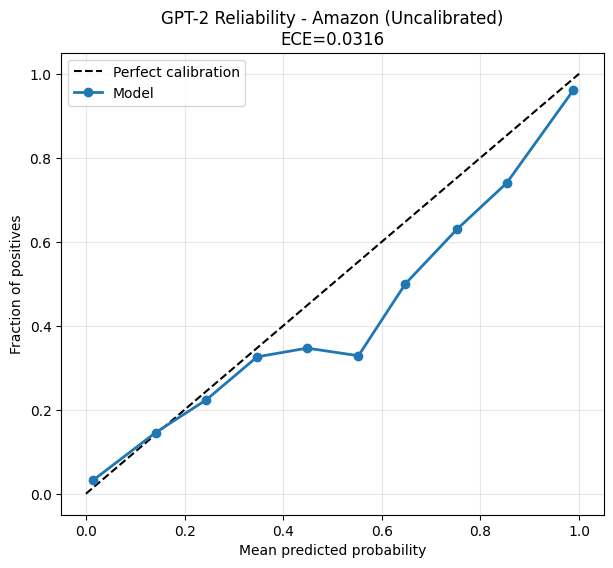

In [ ]:
# GPT-2: Evaluation helpers + in-domain and domain-shift baseline
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lower, upper = bins[i], bins[i + 1]
        in_bin = (y_prob > lower) & (y_prob <= upper)
        if np.any(in_bin):
            acc_bin = np.mean(y_true[in_bin])
            conf_bin = np.mean(y_prob[in_bin])
            ece += np.abs(acc_bin - conf_bin) * np.mean(in_bin)
    return float(ece)

def brier_score(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    return float(np.mean((y_true - y_prob) ** 2))

def maximum_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    mce = 0.0
    for i in range(n_bins):
        lower, upper = bins[i], bins[i + 1]
        in_bin = (y_prob > lower) & (y_prob <= upper)
        if np.any(in_bin):
            acc_bin = np.mean(y_true[in_bin])
            conf_bin = np.mean(y_prob[in_bin])
            mce = max(mce, np.abs(acc_bin - conf_bin))
    return float(mce)

def softmax_np(logits):
    z = logits - np.max(logits, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def predict_with_trainer(trainer, dataset):
    out = trainer.predict(dataset)
    logits = out.predictions
    labels = out.label_ids
    probs = softmax_np(logits)
    preds = np.argmax(probs, axis=-1)
    pos_probs = probs[:, 1]
    return preds, pos_probs, labels, logits

def evaluate_all_metrics(y_true, y_pred, y_prob, title):
    acc = accuracy_score(y_true, y_pred)
    ece = expected_calibration_error(y_true, y_prob, n_bins=10)
    brier = brier_score(y_true, y_prob)
    mce = maximum_calibration_error(y_true, y_prob, n_bins=10)
    print(f"\n{title}")
    print("=" * len(title))
    print(f"Accuracy: {acc:.4f}")
    print(f"ECE:      {ece:.4f}")
    print(f"Brier:    {brier:.4f}")
    print(f"MCE:      {mce:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))
    return {"accuracy": acc, "ece": ece, "brier": brier, "mce": mce}

def plot_reliability(y_true, y_prob, title, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="uniform")
    ece = expected_calibration_error(y_true, y_prob, n_bins=n_bins)
    plt.figure(figsize=(7, 6))
    plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    plt.plot(mean_pred, frac_pos, marker="o", linewidth=2, label="Model")
    plt.title(f"{title}\nECE={ece:.4f}")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# In-domain evaluation (IMDb test)
gpt2_test_preds, gpt2_test_probs, gpt2_test_labels, gpt2_test_logits = predict_with_trainer(trainer_gpt2, test_ds)
gpt2_imdb_baseline = evaluate_all_metrics(
    gpt2_test_labels, gpt2_test_preds, gpt2_test_probs,
    "GPT-2 Baseline - IMDb Test"
 )
plot_reliability(gpt2_test_labels, gpt2_test_probs, "GPT-2 Reliability - IMDb (Uncalibrated)")

# Domain-shift evaluation (Amazon Polarity)
print("\nLoading Amazon Polarity for domain-shift test...")
amazon_raw = load_dataset("amazon_polarity", split="test[:5000]")

def preprocess_amazon(batch):
    texts = [t + " " + c for t, c in zip(batch["title"], batch["content"])]
    tok = tokenizer_gpt2(texts, truncation=True, padding="max_length", max_length=MAX_LEN)
    tok["labels"] = batch["label"]
    return tok

amazon_ds = amazon_raw.map(preprocess_amazon, batched=True)
amazon_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

gpt2_amz_preds, gpt2_amz_probs, gpt2_amz_labels, gpt2_amz_logits = predict_with_trainer(trainer_gpt2, amazon_ds)
gpt2_amazon_baseline = evaluate_all_metrics(
    gpt2_amz_labels, gpt2_amz_preds, gpt2_amz_probs,
    "GPT-2 Baseline - Amazon (Domain Shift)"
 )
plot_reliability(gpt2_amz_labels, gpt2_amz_probs, "GPT-2 Reliability - Amazon (Uncalibrated)")

## GPT-2 Domain-Shift Note

GPT-2 is evaluated on Amazon Reviews as an out-of-domain test set to measure robustness and calibration stability after training on IMDb. This provides a consistent comparison with the DistilBERT and RoBERTa Amazon domain-shift results.

CardiffNLP was evaluated only for DistilBERT and not for GPT-2 due to computational constraints, so cross-model domain-shift comparison is limited to Amazon Reviews.


IMDb Test - Uncalibrated
Accuracy: 0.9226
ECE:      0.0353
Brier:    0.0608
MCE:      0.1235

Classification report:
              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92     12500
    Positive       0.92      0.92      0.92     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000


IMDb Test - Temperature Scaling
Accuracy: 0.9226
ECE:      0.0070
Brier:    0.0582
MCE:      0.0576

Classification report:
              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92     12500
    Positive       0.92      0.92      0.92     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000


IMDb Test - Platt Scaling
Accuracy: 0.8408
ECE:      0.0499
Brier:    0.1253
MCE:      0.0888

Classif

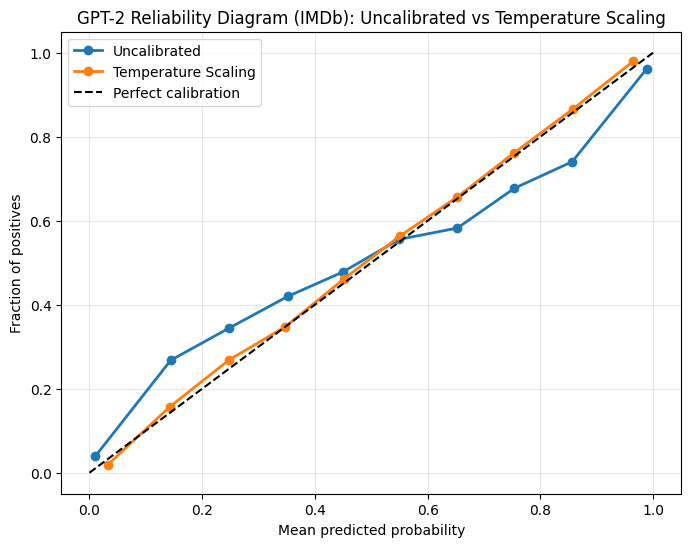

In [ ]:
# GPT-2: Post-hoc calibration (Temperature, Platt, Isotonic) and comparison
class TemperatureScaling:
    def __init__(self):
        self.temperature = 1.0

    def fit(self, logits, labels, lr=0.01, max_iter=100):
        logits_t = torch.tensor(logits, dtype=torch.float32)
        labels_t = torch.tensor(labels, dtype=torch.long)
        temp = torch.nn.Parameter(torch.ones(1) * 1.5)
        opt = torch.optim.LBFGS([temp], lr=lr, max_iter=max_iter)

        def closure():
            opt.zero_grad()
            loss = torch.nn.functional.cross_entropy(logits_t / temp, labels_t)
            loss.backward()
            return loss

        opt.step(closure)
        self.temperature = float(temp.detach().item())
        return self

    def predict_proba(self, logits):
        scaled = logits / self.temperature
        return softmax_np(scaled)[:, 1]

class PlattScaling:
    def __init__(self):
        self.model = LogisticRegression(solver="lbfgs", max_iter=1000)

    def fit(self, logits, labels):
        self.model.fit(logits[:, 1].reshape(-1, 1), labels)
        return self

    def predict_proba(self, logits):
        return self.model.predict_proba(logits[:, 1].reshape(-1, 1))[:, 1]

class IsotonicCalibration:
    def __init__(self):
        self.model = IsotonicRegression(out_of_bounds="clip")

    def fit(self, probs, labels):
        self.model.fit(probs, labels)
        return self

    def predict_proba(self, probs):
        return self.model.predict(probs)

# Validation predictions for fitting calibrators
gpt2_val_preds, gpt2_val_probs, gpt2_val_labels, gpt2_val_logits = predict_with_trainer(trainer_gpt2, val_ds)

temp_scaler_gpt2 = TemperatureScaling().fit(gpt2_val_logits, gpt2_val_labels)
platt_scaler_gpt2 = PlattScaling().fit(gpt2_val_logits, gpt2_val_labels)
isotonic_scaler_gpt2 = IsotonicCalibration().fit(gpt2_val_probs, gpt2_val_labels)

calibrators_gpt2 = {
    "Temperature Scaling": temp_scaler_gpt2,
    "Platt Scaling": platt_scaler_gpt2,
    "Isotonic Regression": isotonic_scaler_gpt2,
}

def evaluate_calibrators(dataset_name, labels, logits, probs):
    rows = []
    rows.append({"dataset": dataset_name, "method": "Uncalibrated", **evaluate_all_metrics(labels, (probs > 0.5).astype(int), probs, f"{dataset_name} - Uncalibrated")})
    for name, cal in calibrators_gpt2.items():
        if name == "Isotonic Regression":
            cal_probs = cal.predict_proba(probs)
        else:
            cal_probs = cal.predict_proba(logits)
        cal_preds = (cal_probs > 0.5).astype(int)
        metrics = evaluate_all_metrics(labels, cal_preds, cal_probs, f"{dataset_name} - {name}")
        rows.append({"dataset": dataset_name, "method": name, **metrics})
    return rows

summary_rows = []
summary_rows += evaluate_calibrators("IMDb Test", gpt2_test_labels, gpt2_test_logits, gpt2_test_probs)
summary_rows += evaluate_calibrators("Amazon", gpt2_amz_labels, gpt2_amz_logits, gpt2_amz_probs)

summary_df = pd.DataFrame(summary_rows)
print("\nCalibration summary:")
print(summary_df.round(4))

# Reliability diagram comparison: IMDb uncalibrated vs temperature-scaled
imdb_temp_probs = temp_scaler.predict_proba(gpt2_test_logits)
plt.figure(figsize=(8, 6))
for probs, name in [(gpt2_test_probs, "Uncalibrated"), (imdb_temp_probs, "Temperature Scaling")]:
    frac_pos, mean_pred = calibration_curve(gpt2_test_labels, probs, n_bins=10, strategy="uniform")
    plt.plot(mean_pred, frac_pos, marker="o", linewidth=2, label=name)
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.title("GPT-2 Reliability Diagram (IMDb): Uncalibrated vs Temperature Scaling")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
print("Creating domain_shift_results_gpt2 structure...")
# 1. Initialize an empty dictionary named domain_shift_results_gpt2.
domain_shift_results_gpt2 = {}

# 2. Populate domain_shift_results_gpt2 with the Amazon Reviews dataset results for GPT-2
domain_shift_results_gpt2['Amazon Reviews'] = {
    'labels': gpt2_amz_labels,
    'predictions': gpt2_amz_preds,
    'probabilities': gpt2_amz_probs,
    'logits': gpt2_amz_logits,
    'metrics': gpt2_amazon_baseline
}

print("GPT-2 domain shift results structure created!")

Creating domain_shift_results_gpt2 structure...
GPT-2 domain shift results structure created!


In [ ]:
print("\nGPT-2 Performance Summary on Amazon Reviews (Domain Shift)")
gpt2_amz_acc = gpt2_amazon_baseline['accuracy']
gpt2_amz_ece = gpt2_amazon_baseline['ece']

gpt2_acc_drop = gpt2_imdb_baseline['accuracy'] - gpt2_amz_acc
gpt2_ece_increase = gpt2_amz_ece - gpt2_imdb_baseline['ece']

print(f"Accuracy on Amazon Reviews: {gpt2_amz_acc:.4f}")
print(f"ECE on Amazon Reviews: {gpt2_amz_ece:.4f}")
print(f"Accuracy Drop from IMDb Baseline: {gpt2_acc_drop:.4f} ({gpt2_acc_drop*100:.2f}%)")
print(f"ECE Increase from IMDb Baseline: {gpt2_ece_increase:+.4f}")



GPT-2 Performance Summary on Amazon Reviews (Domain Shift)
Accuracy on Amazon Reviews: 0.9216
ECE on Amazon Reviews: 0.0316
Accuracy Drop from IMDb Baseline: 0.0010 (0.10%)
ECE Increase from IMDb Baseline: -0.0037


DOMAIN SHIFT ROBUSTNESS COMPARISON


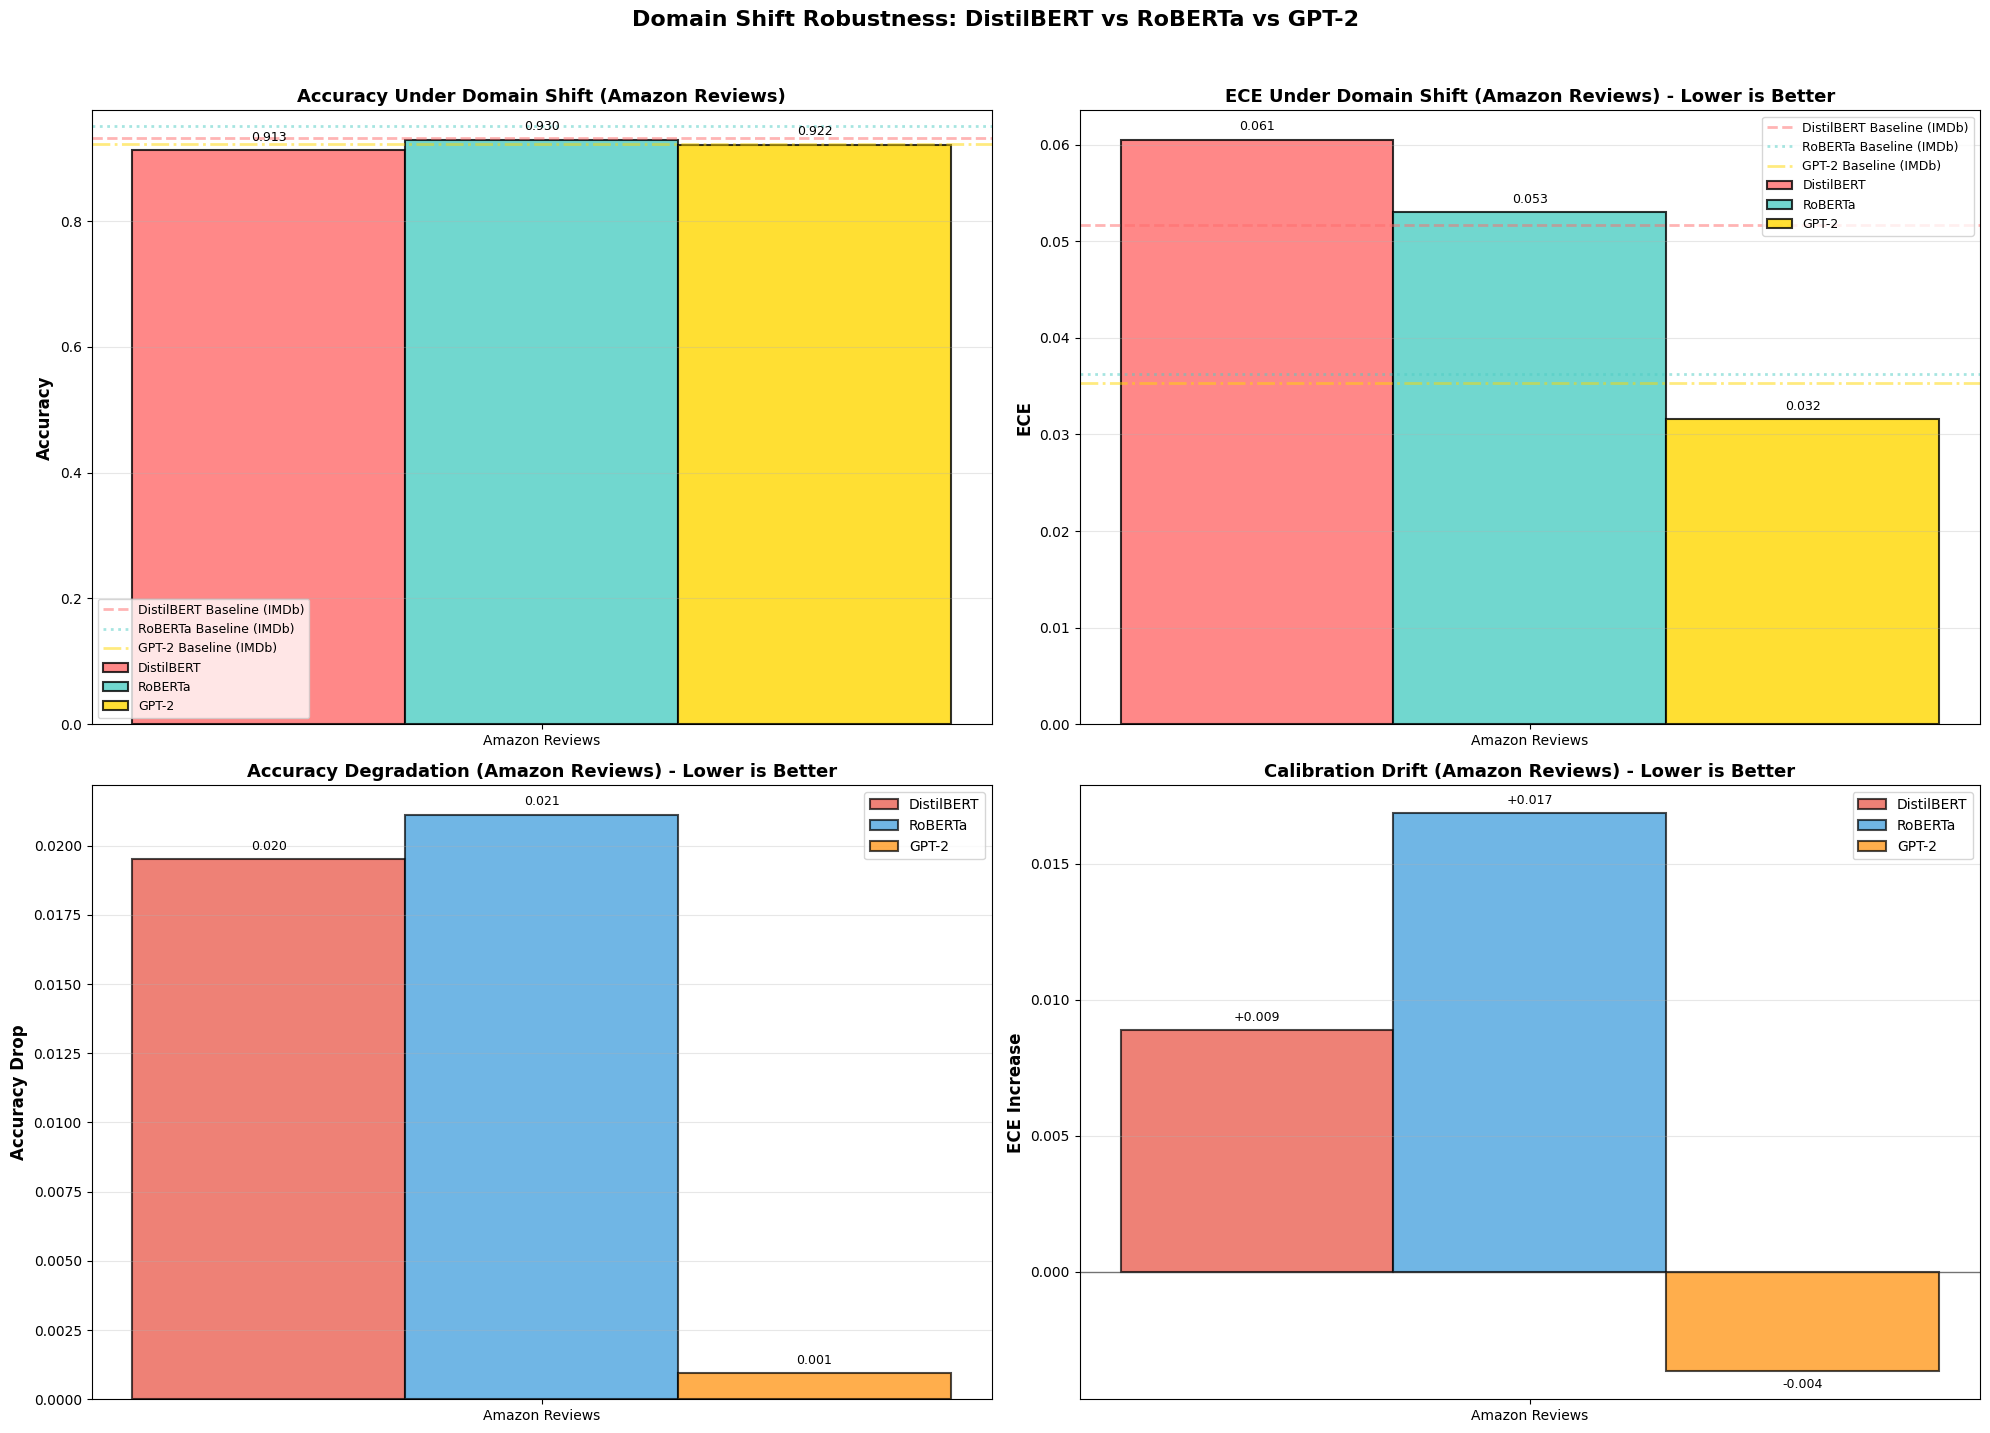


Domain shift robustness comparison (with GPT-2) saved as 'domain_shift_robustness_comparison_with_gpt2.png'


In [ ]:
print("DOMAIN SHIFT ROBUSTNESS COMPARISON")

def add_bar_labels(ax, bars, fmt="{:.3f}", pos_pad_frac=0.01, neg_pad_frac=0.01, fontsize=9):
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    pos_pad = y_range * pos_pad_frac
    neg_pad = y_range * neg_pad_frac

    for bar in bars:
        h = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2

        if h >= 0:
            ax.text(x, h + pos_pad, fmt.format(h),
                    ha='center', va='bottom', fontsize=fontsize)
        else:
            ax.text(x, h - neg_pad, fmt.format(h),
                    ha='center', va='top', fontsize=fontsize)

if domain_shift_results and domain_shift_results_2 and domain_shift_results_gpt2:
    # Find common domains across all three models
    common_domains = sorted(
        set(domain_shift_results.keys()) &
        set(domain_shift_results_2.keys()) &
        set(domain_shift_results_gpt2.keys())
    )

    # Focus on Amazon Reviews only if available
    domains_to_plot = [d for d in ['Amazon Reviews'] if d in common_domains]

    if len(domains_to_plot) > 0:
        n_domains = len(domains_to_plot)

        fig, axes = plt.subplots(2, 2, figsize=(20, 14))
        fig.suptitle(
            'Domain Shift Robustness: DistilBERT vs RoBERTa vs GPT-2',
            fontsize=16,
            fontweight='bold',
            y=1.02
        )

        x = np.arange(n_domains)
        width = 0.2

        # Collect metrics
        distilbert_domain_acc = [domain_shift_results[d]['metrics']['accuracy'] for d in domains_to_plot]
        roberta_domain_acc = [domain_shift_results_2[d]['metrics']['accuracy'] for d in domains_to_plot]
        gpt2_domain_acc = [domain_shift_results_gpt2[d]['metrics']['accuracy'] for d in domains_to_plot]

        distilbert_domain_ece = [domain_shift_results[d]['metrics']['ece'] for d in domains_to_plot]
        roberta_domain_ece = [domain_shift_results_2[d]['metrics']['ece'] for d in domains_to_plot]
        gpt2_domain_ece = [domain_shift_results_gpt2[d]['metrics']['ece'] for d in domains_to_plot]

        # Baseline comparisons
        distilbert_acc_drop = [baseline_results['accuracy'] - acc for acc in distilbert_domain_acc]
        roberta_acc_drop = [baseline_results_2['accuracy'] - acc for acc in roberta_domain_acc]
        gpt2_acc_drop = [gpt2_imdb_baseline['accuracy'] - acc for acc in gpt2_domain_acc]

        distilbert_ece_increase = [ece - baseline_results['ece'] for ece in distilbert_domain_ece]
        roberta_ece_increase = [ece - baseline_results_2['ece'] for ece in roberta_domain_ece]
        gpt2_ece_increase = [ece - gpt2_imdb_baseline['ece'] for ece in gpt2_domain_ece]

        # ---------------- Plot 1: Accuracy Under Domain Shift ----------------
        ax = axes[0, 0]
        bars1 = ax.bar(x - width, distilbert_domain_acc, width, label='DistilBERT',
                       color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.5)
        bars2 = ax.bar(x, roberta_domain_acc, width, label='RoBERTa',
                       color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=1.5)
        bars3 = ax.bar(x + width, gpt2_domain_acc, width, label='GPT-2',
                       color='#FFD700', alpha=0.8, edgecolor='black', linewidth=1.5)

        ax.axhline(y=baseline_results['accuracy'], color='#FF6B6B',
                   linestyle='--', linewidth=2, alpha=0.5, label='DistilBERT Baseline (IMDb)')
        ax.axhline(y=baseline_results_2['accuracy'], color='#4ECDC4',
                   linestyle=':', linewidth=2, alpha=0.5, label='RoBERTa Baseline (IMDb)')
        ax.axhline(y=gpt2_imdb_baseline['accuracy'], color='#FFD700',
                   linestyle='-.', linewidth=2, alpha=0.5, label='GPT-2 Baseline (IMDb)')

        ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
        ax.set_title('Accuracy Under Domain Shift (Amazon Reviews)', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(domains_to_plot, fontsize=10)
        ax.legend(fontsize=9, loc='lower left')
        ax.grid(True, alpha=0.3, axis='y')

        add_bar_labels(ax, bars1)
        add_bar_labels(ax, bars2)
        add_bar_labels(ax, bars3)

        # ---------------- Plot 2: ECE Under Domain Shift ----------------
        ax = axes[0, 1]
        bars1 = ax.bar(x - width, distilbert_domain_ece, width, label='DistilBERT',
                       color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.5)
        bars2 = ax.bar(x, roberta_domain_ece, width, label='RoBERTa',
                       color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=1.5)
        bars3 = ax.bar(x + width, gpt2_domain_ece, width, label='GPT-2',
                       color='#FFD700', alpha=0.8, edgecolor='black', linewidth=1.5)

        ax.axhline(y=baseline_results['ece'], color='#FF6B6B',
                   linestyle='--', linewidth=2, alpha=0.5, label='DistilBERT Baseline (IMDb)')
        ax.axhline(y=baseline_results_2['ece'], color='#4ECDC4',
                   linestyle=':', linewidth=2, alpha=0.5, label='RoBERTa Baseline (IMDb)')
        ax.axhline(y=gpt2_imdb_baseline['ece'], color='#FFD700',
                   linestyle='-.', linewidth=2, alpha=0.5, label='GPT-2 Baseline (IMDb)')

        ax.set_ylabel('ECE', fontsize=12, fontweight='bold')
        ax.set_title('ECE Under Domain Shift (Amazon Reviews) - Lower is Better', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(domains_to_plot, fontsize=10)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(True, alpha=0.3, axis='y')

        add_bar_labels(ax, bars1)
        add_bar_labels(ax, bars2)
        add_bar_labels(ax, bars3)

        # ---------------- Plot 3: Accuracy Degradation ----------------
        ax = axes[1, 0]
        bars1 = ax.bar(x - width, distilbert_acc_drop, width, label='DistilBERT',
                       color='#E74C3C', alpha=0.7, edgecolor='black', linewidth=1.5)
        bars2 = ax.bar(x, roberta_acc_drop, width, label='RoBERTa',
                       color='#3498DB', alpha=0.7, edgecolor='black', linewidth=1.5)
        bars3 = ax.bar(x + width, gpt2_acc_drop, width, label='GPT-2',
                       color='#FF8C00', alpha=0.7, edgecolor='black', linewidth=1.5)

        ax.set_ylabel('Accuracy Drop', fontsize=12, fontweight='bold')
        ax.set_title('Accuracy Degradation (Amazon Reviews) - Lower is Better', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(domains_to_plot, fontsize=10)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')

        add_bar_labels(ax, bars1)
        add_bar_labels(ax, bars2)
        add_bar_labels(ax, bars3)

        # ---------------- Plot 4: Calibration Drift ----------------
        ax = axes[1, 1]
        bars1 = ax.bar(x - width, distilbert_ece_increase, width, label='DistilBERT',
                       color='#E74C3C', alpha=0.7, edgecolor='black', linewidth=1.5)
        bars2 = ax.bar(x, roberta_ece_increase, width, label='RoBERTa',
                       color='#3498DB', alpha=0.7, edgecolor='black', linewidth=1.5)
        bars3 = ax.bar(x + width, gpt2_ece_increase, width, label='GPT-2',
                       color='#FF8C00', alpha=0.7, edgecolor='black', linewidth=1.5)

        ax.set_ylabel('ECE Increase', fontsize=12, fontweight='bold')
        ax.set_title('Calibration Drift (Amazon Reviews) - Lower is Better', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(domains_to_plot, fontsize=10)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

        add_bar_labels(ax, bars1, fmt="{:+.3f}")
        add_bar_labels(ax, bars2, fmt="{:+.3f}")
        add_bar_labels(ax, bars3, fmt="{:+.3f}")

        plt.tight_layout()
        plt.savefig('domain_shift_robustness_comparison_with_gpt2.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("\nDomain shift robustness comparison (with GPT-2) saved as 'domain_shift_robustness_comparison_with_gpt2.png'")
    else:
        print("Amazon Reviews not available in all three model results.")
else:
    print("Domain shift results not available for all three models (DistilBERT, RoBERTa, GPT-2).")

In [ ]:
# Filter summary_df for IMDb Test and specific methods
imdb_summary = summary_df[summary_df['dataset'] == 'IMDb Test']

# Map for matching labels in summary_df to the visualization method list
# Visualization methods: ['Uncalibrated', 'Temperature\nScaling', 'Platt\nScaling', 'Isotonic\nRegression']
method_map = {
    'Uncalibrated': 'Uncalibrated',
    'Temperature\nScaling': 'Temperature Scaling',
    'Platt\nScaling': 'Platt Scaling',
    'Isotonic\nRegression': 'Isotonic Regression'
}

# Define labels for the calibration methods - MOVED FROM NEXT CELL
methods = ['Uncalibrated', 'Temperature\nScaling', 'Platt\nScaling', 'Isotonic\nRegression']

# Extraction following the order in 'methods'
gpt2_acc = []
gpt2_ece = []
gpt2_brier = []
gpt2_mce = []

for m in methods:
    row = imdb_summary[imdb_summary['method'] == method_map[m]]
    gpt2_acc.append(row['accuracy'].values[0])
    gpt2_ece.append(row['ece'].values[0])
    gpt2_brier.append(row['brier'].values[0])
    gpt2_mce.append(row['mce'].values[0])

print("GPT-2 Metrics Extracted (IMDb Test):")
print(f"Methods: {methods}")
print(f"Accuracy: {gpt2_acc}")
print(f"ECE:      {gpt2_ece}")
print(f"Brier:    {gpt2_brier}")
print(f"MCE:      {gpt2_mce}")

GPT-2 Metrics Extracted (IMDb Test):
Methods: ['Uncalibrated', 'Temperature\nScaling', 'Platt\nScaling', 'Isotonic\nRegression']
Accuracy: [np.float64(0.92256), np.float64(0.92256), np.float64(0.84076), np.float64(0.92188)]
ECE:      [np.float64(0.03528012171711771), np.float64(0.006959635894298566), np.float64(0.0499164925582246), np.float64(0.009369654376655828)]
Brier:    [np.float64(0.060834621207484285), np.float64(0.05819319343926837), np.float64(0.12532376790235727), np.float64(0.05835392404967302)]
MCE:      [np.float64(0.12351473520590567), np.float64(0.05755582333897516), np.float64(0.0888232023959862), np.float64(0.056960642192066424)]


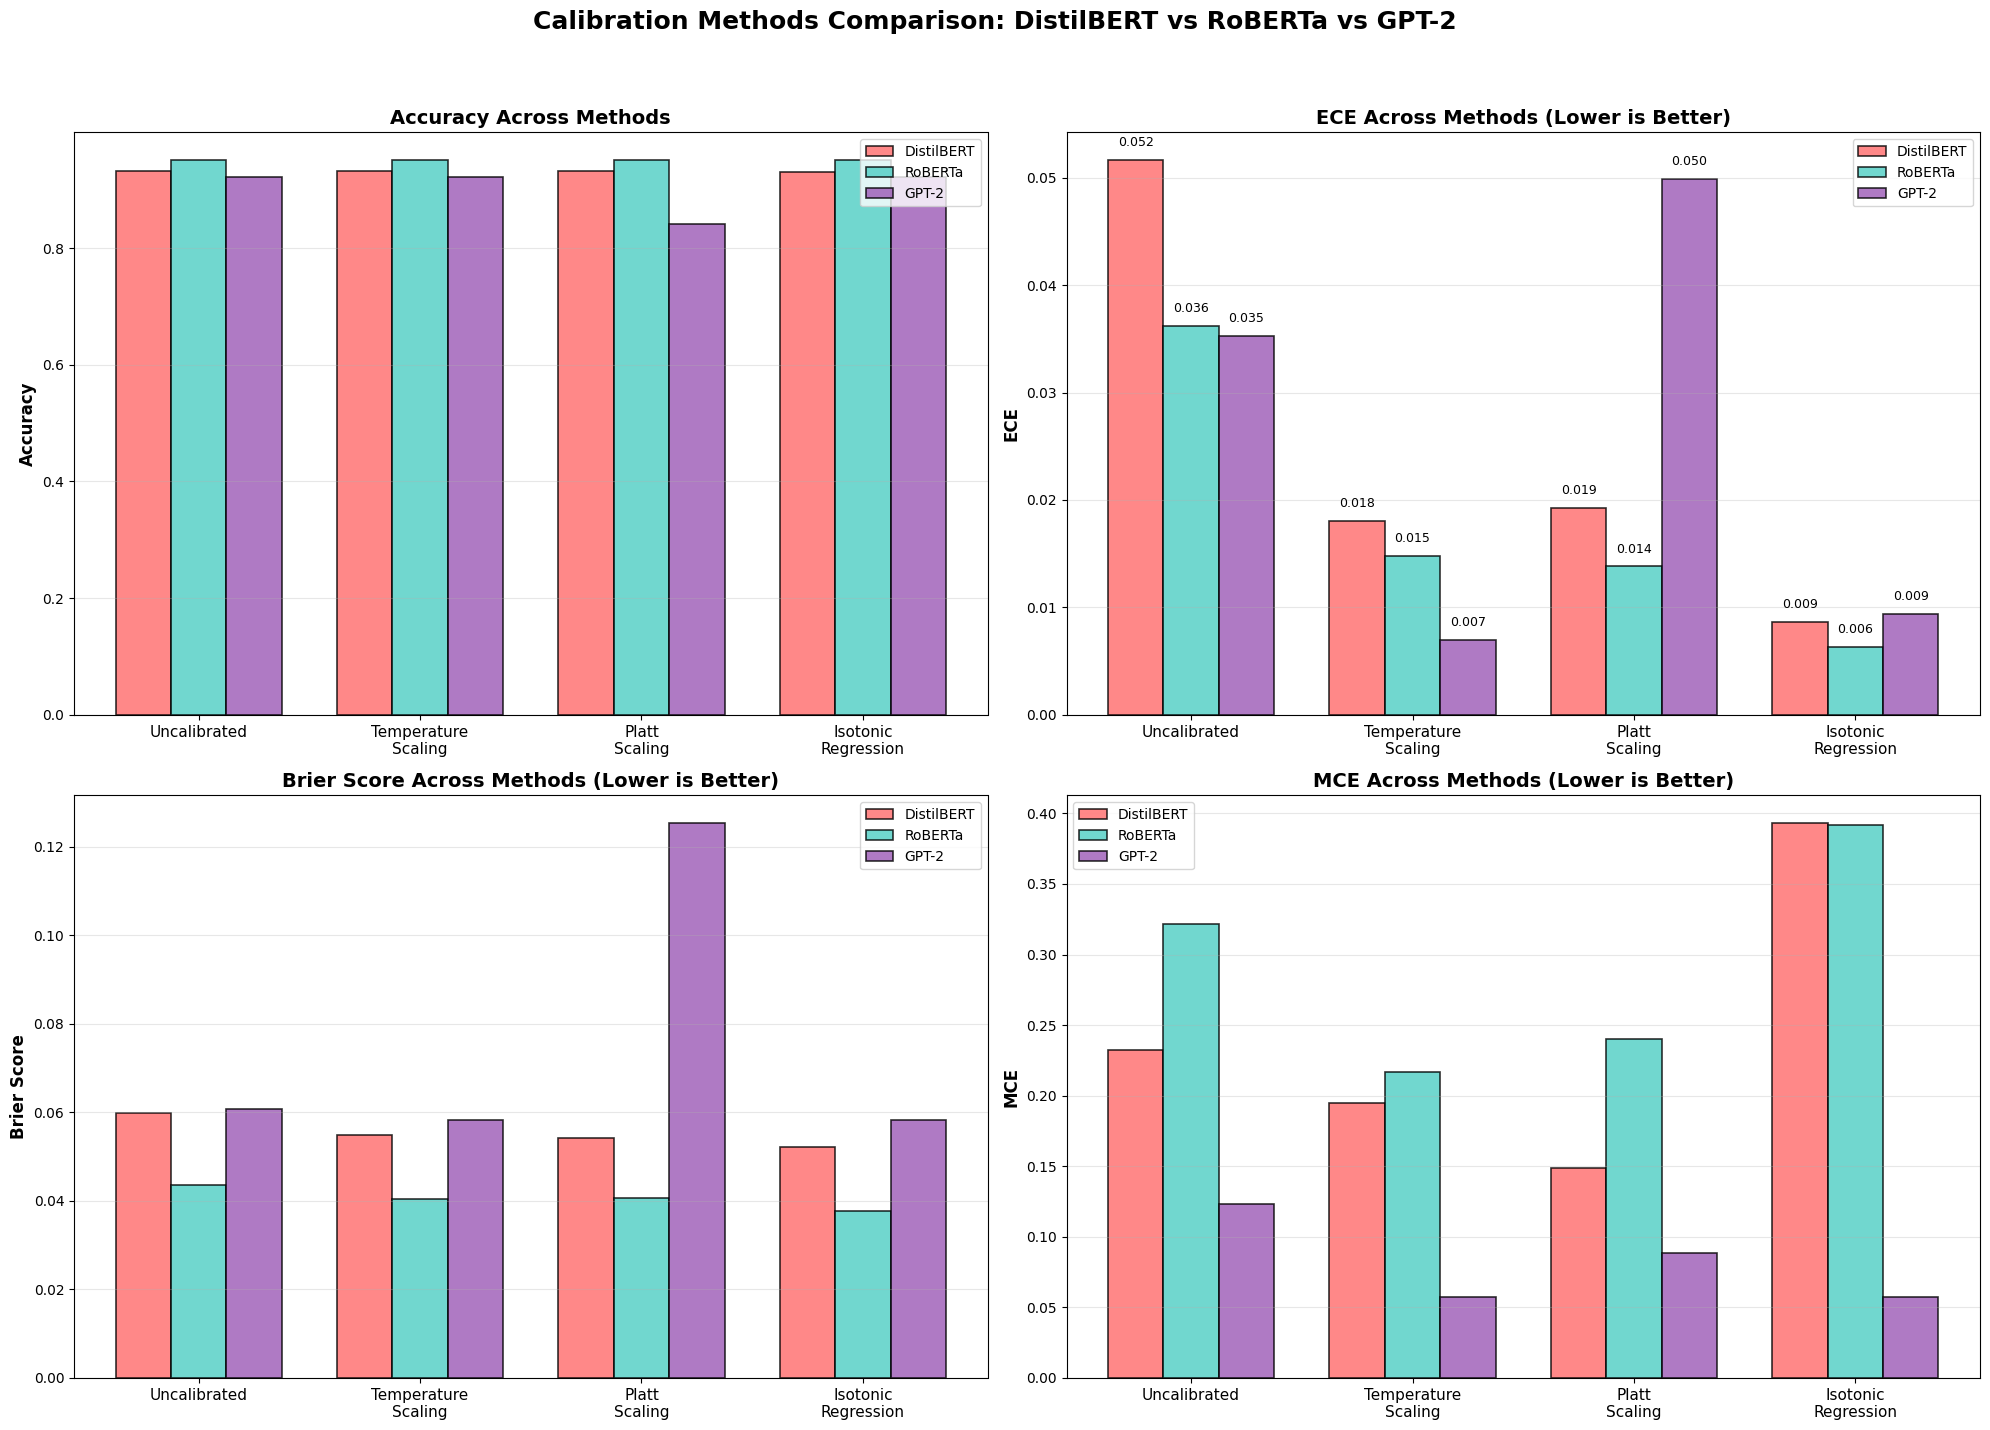

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define labels for the calibration methods
methods = ['Uncalibrated', 'Temperature\nScaling', 'Platt\nScaling', 'Isotonic\nRegression']
x = np.arange(len(methods))
width = 0.25  # Adjusted width for three bars

# 2. Consolidate metrics for DistilBERT and RoBERTa (GPT-2 lists gpt2_acc etc. already exist from previous step)
distilbert_acc = [baseline_results['accuracy']] + [calibrated_results[m]['metrics']['accuracy'] for m in calibrators.keys()]
roberta_acc = [baseline_results_2['accuracy']] + [calibrated_results_2[m]['metrics']['accuracy'] for m in calibrators_2.keys()]

distilbert_ece = [baseline_results['ece']] + [calibrated_results[m]['metrics']['ece'] for m in calibrators.keys()]
roberta_ece = [baseline_results_2['ece']] + [calibrated_results_2[m]['metrics']['ece'] for m in calibrators_2.keys()]

distilbert_brier = [baseline_results['brier']] + [calibrated_results[m]['metrics']['brier'] for m in calibrators.keys()]
roberta_brier = [baseline_results_2['brier']] + [calibrated_results_2[m]['metrics']['brier'] for m in calibrators_2.keys()]

distilbert_mce = [baseline_results['mce']] + [calibrated_results[m]['metrics']['mce'] for m in calibrators.keys()]
roberta_mce = [baseline_results_2['mce']] + [calibrated_results_2[m]['metrics']['mce'] for m in calibrators_2.keys()]

# 3. Set up matplotlib figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Calibration Methods Comparison: DistilBERT vs RoBERTa vs GPT-2', fontsize=18, fontweight='bold')

# Define colors
colors = ['#FF6B6B', '#4ECDC4', '#9B59B6'] # DistilBERT, RoBERTa, GPT-2
labels = ['DistilBERT', 'RoBERTa', 'GPT-2']

# 4 & 5. Plotting logic for each subplot
metrics_data = [
    (distilbert_acc, roberta_acc, gpt2_acc, 'Accuracy', 'Accuracy Across Methods'),
    (distilbert_ece, roberta_ece, gpt2_ece, 'ECE', 'ECE Across Methods (Lower is Better)'),
    (distilbert_brier, roberta_brier, gpt2_brier, 'Brier Score', 'Brier Score Across Methods (Lower is Better)'),
    (distilbert_mce, roberta_mce, gpt2_mce, 'MCE', 'MCE Across Methods (Lower is Better)')
]

for i, (d_vals, r_vals, g_vals, ylabel, title) in enumerate(metrics_data):
    ax = axes[i // 2, i % 2]

    # Plot three distinct offsets
    ax.bar(x - width, d_vals, width, label=labels[0], color=colors[0], alpha=0.8, edgecolor='black', linewidth=1.2)
    ax.bar(x, r_vals, width, label=labels[1], color=colors[1], alpha=0.8, edgecolor='black', linewidth=1.2)
    ax.bar(x + width, g_vals, width, label=labels[2], color=colors[2], alpha=0.8, edgecolor='black', linewidth=1.2)

    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # 6. Add value annotations for ECE subplot
    if ylabel == 'ECE':
        for j in range(len(methods)):
            ax.text(x[j] - width, d_vals[j] + 0.001, f'{d_vals[j]:.3f}', ha='center', va='bottom', fontsize=9, rotation=0)
            ax.text(x[j], r_vals[j] + 0.001, f'{r_vals[j]:.3f}', ha='center', va='bottom', fontsize=9, rotation=0)
            ax.text(x[j] + width, g_vals[j] + 0.001, f'{g_vals[j]:.3f}', ha='center', va='bottom', fontsize=9, rotation=0)

# 7 & 8. Save and Display
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('calibration_methods_detailed_comparison_v2.png', dpi=300, bbox_inches='tight')
plt.show()

## Final Conclusion

This project shows that sentiment classification should be evaluated using both predictive performance and calibration quality. RoBERTa achieves the strongest in-domain accuracy on IMDb, while all three uncalibrated models show some degree of overconfidence.

Under domain shift, accuracy and calibration both become more challenging, showing that good in-domain performance does not guarantee reliable behaviour on new data. Post calibration methods improve the trustworthiness of predicted probabilities, although the best calibration method varies by model. Overall, the results support the importance of combining robustness testing with calibration analysis when evaluating sentiment models for real-world use.